In [1]:
import os
os.makedirs('plots', exist_ok=True)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from scipy import stats

# import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GLOBAL CONFIG ─────────────────────────────────────────────
DATA_PATH = "/kaggle/input/competitions/home-credit-default-risk/"
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 1: Load Data

Home Credit provides **7 relational tables**. The main table `application_train.csv` contains one row per loan application with the binary `TARGET` (1 = defaulted). The six auxiliary tables carry historical bureau, POS, credit card, previous application and instalment data these encode rich behavioural signals.

Steps 2–5 will aggregate each auxiliary table into **per-applicant summary features** before merging them onto the main table in Step 7.

In [2]:
print('Loading data...')

app    = pd.read_csv(DATA_PATH + 'application_train.csv')
bureau = pd.read_csv(DATA_PATH + 'bureau.csv')
bb     = pd.read_csv(DATA_PATH + 'bureau_balance.csv')
pos    = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv')
cc     = pd.read_csv(DATA_PATH + 'credit_card_balance.csv')
prev   = pd.read_csv(DATA_PATH + 'previous_application.csv')
inst   = pd.read_csv(DATA_PATH + 'installments_payments.csv')

tables = {
    'application_train' : app,
    'bureau'            : bureau,
    'bureau_balance'    : bb,
    'POS_CASH_balance'  : pos,
    'credit_card'       : cc,
    'previous_app'      : prev,
    'installments'      : inst,
}

print('\n{:<25} {:>10} {:>10}'.format('Table', 'Rows', 'Cols'))
print('-' * 47)
for name, df in tables.items():
    print('{:<25} {:>10,} {:>10}'.format(name, len(df), len(df.columns)))

print('\nTarget distribution:')
print(app['TARGET'].value_counts())
print(f'\nDefault rate: {app["TARGET"].mean():.2%}')

Loading data...

Table                           Rows       Cols
-----------------------------------------------
application_train            307,511        122
bureau                     1,716,428         17
bureau_balance            27,299,925          3
POS_CASH_balance          10,001,358          8
credit_card                3,840,312         23
previous_app               1,670,214         37
installments              13,605,401          8

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


## Step 2: Bureau Table Cleaning

The `bureau.csv` table records each applicant's **credit history reported to the Credit Bureau** (analogous to CIBIL/TransUnion in India or Experian/Equifax internationally). It contains multiple rows per applicant — one per external credit account.

**Why it matters:** Bureau data is the single strongest predictor in most PD models. Regulators (RBI, Basel) require banks to incorporate bureau scores and delinquency history.

We aggregate the bureau balance (monthly statuses) and then the bureau table itself into **one row per applicant** using counts, sums, means and worst-case statistics. This is part of a 6-table aggregation pipeline (Steps 2–5) before the final merge in Step 7.

In [3]:
# ── STEP 2: BUREAU TABLE CLEANING ──────────────────────────
print('Aggregating bureau tables...')

# Bureau balance: status counts per bureau credit
bb_agg = bb.groupby('SK_ID_BUREAU').agg(
    bb_months_count = ('MONTHS_BALANCE', 'count'),
    bb_status_mean  = ('STATUS', lambda x: x.astype(str).map(
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'C':0,'X':0}
    ).mean()),
).reset_index()

bureau_with_bb = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

# Aggregate bureau to SK_ID_CURR level
bureau_agg = bureau_with_bb.groupby('SK_ID_CURR').agg(
    bureau_count            = ('SK_ID_BUREAU', 'count'),
    bureau_active_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_closed_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    bureau_days_credit_mean = ('DAYS_CREDIT', 'mean'),
    bureau_days_credit_min  = ('DAYS_CREDIT', 'min'),
    bureau_credit_end_mean  = ('DAYS_CREDIT_ENDDATE', 'mean'),
    bureau_amt_credit_sum   = ('AMT_CREDIT_SUM', 'sum'),
    bureau_amt_credit_mean  = ('AMT_CREDIT_SUM', 'mean'),
    bureau_amt_overdue_sum  = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    bureau_dpd_max          = ('CREDIT_DAY_OVERDUE', 'max'),
    bureau_dpd_mean         = ('CREDIT_DAY_OVERDUE', 'mean'),
    bureau_prolonged_sum    = ('CNT_CREDIT_PROLONG', 'sum'),
    bureau_bb_months_mean   = ('bb_months_count', 'mean'),
    bureau_bb_status_mean   = ('bb_status_mean', 'mean'),
).reset_index()

print(f'Bureau aggregated: {bureau_agg.shape}')

Aggregating bureau tables...
Bureau aggregated: (305811, 15)


## Step 3: POS Cash & Installments Aggregation

**POS Cash Balance** (`POS_CASH_balance.csv`) tracks monthly snapshots of Home Credit's own consumer loans and POS loans capturing payment behaviour on active and completed contracts.

**Installments Payments** (`installments_payments.csv`) records every scheduled vs. actual payment; the key signals are payment timing (days late/early) and payment shortfall (underpayment ratio).

These behavioural features often carry strong predictive power for near-term default because they reflect the applicant's current payment discipline, not just historical credit history.

In [4]:
# ── STEP 3: POS CASH & INSTALLMENTS ────────────────────────
print('Aggregating POS and installments...')

# POS Cash Balance aggregation
pos_agg = pos.groupby('SK_ID_CURR').agg(
    pos_count               = ('SK_ID_PREV', 'count'),
    pos_months_balance_mean = ('MONTHS_BALANCE', 'mean'),
    pos_cnt_instalment_mean = ('CNT_INSTALMENT', 'mean'),
    pos_dpd_mean            = ('SK_DPD', 'mean'),
    pos_dpd_max             = ('SK_DPD', 'max'),
    pos_dpd_def_mean        = ('SK_DPD_DEF', 'mean'),
    pos_completed           = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
).reset_index()

# Installments: payment behaviour features
inst['PAYMENT_RATIO']    = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1e-9)
inst['DAYS_LATE']        = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['DAYS_LATE']        = inst['DAYS_LATE'].clip(lower=0)

inst_agg = inst.groupby('SK_ID_CURR').agg(
    inst_count              = ('SK_ID_PREV', 'count'),
    inst_payment_ratio_mean = ('PAYMENT_RATIO', 'mean'),
    inst_payment_ratio_min  = ('PAYMENT_RATIO', 'min'),
    inst_days_late_mean     = ('DAYS_LATE', 'mean'),
    inst_days_late_max      = ('DAYS_LATE', 'max'),
    inst_days_late_sum      = ('DAYS_LATE', 'sum'),
    inst_amt_payment_sum    = ('AMT_PAYMENT', 'sum'),
    inst_amt_payment_mean   = ('AMT_PAYMENT', 'mean'),
).reset_index()

print(f'POS aggregated:   {pos_agg.shape}')
print(f'Inst aggregated:  {inst_agg.shape}')

Aggregating POS and installments...
POS aggregated:   (337252, 8)
Inst aggregated:  (339587, 9)


## Step 4: Credit Card Balance Aggregation

The `credit_card_balance.csv` table contains monthly snapshots of revolving credit card facilities issued by Home Credit. Key risk signals include **utilisation rate** (balance / limit) and **minimum payment behaviour**.

High utilisation (>80%) is one of the strongest short-term default predictors in FICO methodology. It also influences Basel II/III credit conversion factors (CCF) used in EAD estimation.


In [5]:
# ── STEP 4: CREDIT CARD BALANCE ─────────────────────────────
print('Aggregating credit card balance...')

cc['CC_UTIL'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-9)

cc_agg = cc.groupby('SK_ID_CURR').agg(
    cc_count             = ('SK_ID_PREV', 'count'),
    cc_balance_mean      = ('AMT_BALANCE', 'mean'),
    cc_balance_max       = ('AMT_BALANCE', 'max'),
    cc_limit_mean        = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    cc_util_mean         = ('CC_UTIL', 'mean'),
    cc_util_max          = ('CC_UTIL', 'max'),
    cc_drawings_mean     = ('AMT_DRAWINGS_CURRENT', 'mean'),
    cc_drawings_atm_mean = ('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    cc_dpd_mean          = ('SK_DPD', 'mean'),
    cc_dpd_max           = ('SK_DPD', 'max'),
    cc_min_payment_mean  = ('AMT_INST_MIN_REGULARITY', 'mean'),
    cc_receivable_mean   = ('AMT_RECEIVABLE_PRINCIPAL', 'mean'),
).reset_index()

print(f'CC aggregated: {cc_agg.shape}')

Aggregating credit card balance...
CC aggregated: (103558, 13)


## Step 5: Previous Applications Aggregation

The `previous_application.csv` table records all prior loan applications the borrower has made to Home Credit — including approved, refused, cancelled and unused applications.

**Why it matters:** Application behaviour (refusal rate, requested-vs-approved ratio) is a strong proxy for credit demand and lender risk assessment. A high refusal rate from other lenders is a leading indicator of future default.

This completes the **6-table aggregation pipeline** (Steps 2–5). All aggregated tables will be merged onto the main application table in Step 7.

In [6]:
# ── STEP 5: PREVIOUS APPLICATIONS ──────────────────────────
print('Aggregating previous applications...')

prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / (prev['AMT_CREDIT'] + 1e-9)
prev['CREDIT_GOODS_RATIO'] = prev['AMT_CREDIT'] / (prev['AMT_GOODS_PRICE'] + 1e-9)

prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_count              = ('SK_ID_PREV', 'count'),
    prev_approved           = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused            = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_cancelled          = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    prev_amt_credit_mean    = ('AMT_CREDIT', 'mean'),
    prev_amt_credit_sum     = ('AMT_CREDIT', 'sum'),
    prev_amt_annuity_mean   = ('AMT_ANNUITY', 'mean'),
    prev_app_credit_mean    = ('APP_CREDIT_RATIO', 'mean'),
    prev_credit_goods_mean  = ('CREDIT_GOODS_RATIO', 'mean'),
    prev_days_decision_mean = ('DAYS_DECISION', 'mean'),
    prev_hour_appr_mean     = ('HOUR_APPR_PROCESS_START', 'mean'),
    prev_down_payment_mean  = ('AMT_DOWN_PAYMENT', 'mean'),
).reset_index()

prev_agg['prev_approval_rate'] = (
    prev_agg['prev_approved'] / (prev_agg['prev_count'] + 1e-9)
)
prev_agg['prev_refusal_rate'] = (
    prev_agg['prev_refused'] / (prev_agg['prev_count'] + 1e-9)
)

print(f'Previous app aggregated: {prev_agg.shape}')

Aggregating previous applications...
Previous app aggregated: (338857, 15)


## Step 6: Application Table: Cleaning & Encoding

The main application table requires:
1. **Anomaly removal** : replace impossible values (e.g. age in days > 0, meaning future birth dates) with NaN
2. **Categorical encoding** : `LabelEncoder` for tree models (LightGBM handles categoricals natively, but explicit encoding avoids downstream issues)
3. **Missing value imputation** : median for numerics, mode for categoricals

Proper data cleaning is a Basel Model Risk Management (SR 11-7) requirement: models must be validated on clean, representative data.

In [7]:
# ── STEP 6: CLEAN APPLICATION TABLE ────────────────────────
print('Cleaning application table...')

# Replace anomalous values
app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app['DAYS_BIRTH'] = app['DAYS_BIRTH'].abs()
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].abs()
app['DAYS_REGISTRATION'] = app['DAYS_REGISTRATION'].abs()
app['DAYS_ID_PUBLISH'] = app['DAYS_ID_PUBLISH'].abs()
app['DAYS_LAST_PHONE_CHANGE'] = app['DAYS_LAST_PHONE_CHANGE'].abs()

# Encode categoricals
le = LabelEncoder()
cat_cols = app.select_dtypes('object').columns.tolist()
for col in cat_cols:
    app[col].fillna('Unknown', inplace=True)
    app[col] = le.fit_transform(app[col].astype(str))

# Fill remaining numeric NaNs with median
num_cols = app.select_dtypes(include=[np.number]).columns.tolist()
app[num_cols] = app[num_cols].fillna(app[num_cols].median())

print(f'Application cleaned: {app.shape}')
print(f'Remaining NaNs: {app.isnull().sum().sum()}')

Cleaning application table...
Application cleaned: (307511, 122)
Remaining NaNs: 0


## Step 7: Merge All Tables

We left-join all five aggregated auxiliary tables onto the main application table using `SK_ID_CURR` as the key. A left join ensures we retain all 307,511 loan applications even if some have no bureau or POS history (cold-start applicants).

After merging, NaN values in the joined columns are filled with 0 for applicants with no history, zero is semantically correct (0 bureau accounts, 0 previous applications, etc.).

In [8]:
# ── STEP 7: MERGE ALL TABLES ────────────────────────────────
print('Merging all tables...')

df = app.copy()
for agg_df in [bureau_agg, pos_agg, inst_agg, cc_agg, prev_agg]:
    df = df.merge(agg_df, on='SK_ID_CURR', how='left')

# Fill NaN for applicants with no auxiliary history
new_cols = [c for c in df.columns if c not in app.columns]
df[new_cols] = df[new_cols].fillna(0)

print(f'Merged dataset shape: {df.shape}')
print(f'Total features: {df.shape[1] - 2} (excl. SK_ID_CURR, TARGET)')

Merging all tables...
Merged dataset shape: (307511, 177)
Total features: 175 (excl. SK_ID_CURR, TARGET)


In [9]:
print(df.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'prev_amt_credit_mean', 'prev_amt_credit_sum', 'prev_amt_annuity_mean',
       'prev_app_credit_mean', 'prev_credit_goods_mean',
       'prev_days_decision_mean', 'prev_hour_appr_mean',
       'prev_down_payment_mean', 'prev_approval_rate', 'prev_refusal_rate'],
      dtype='object', length=177)


## Step 8: Feature Engineering

We construct **domain-driven ratio features** that combine signals across the dataset. These are informed by standard credit risk practice.

In [10]:
# ── STEP 8: FEATURE ENGINEERING ────────────────────────────
print('Engineering features...')

def safe_div(numer, denom, eps=1e-6):
    return numer / (denom + eps)

# --- Core affordability / burden features ---
df['ANNUITY_INCOME_RATIO']  = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])
df['CREDIT_INCOME_RATIO']   = safe_div(df['AMT_CREDIT'], df['AMT_INCOME_TOTAL'])
df['CREDIT_ANNUITY_RATIO']  = safe_div(df['AMT_CREDIT'], df['AMT_ANNUITY'])
df['GOODS_CREDIT_RATIO']    = safe_div(df['AMT_GOODS_PRICE'], df['AMT_CREDIT'])
df['INCOME_PER_PERSON']     = safe_div(df['AMT_INCOME_TOTAL'], df['CNT_FAM_MEMBERS'] + 1)
df['INCOME_PER_CHILD']      = safe_div(df['AMT_INCOME_TOTAL'], df['CNT_CHILDREN'] + 1)
df['CREDIT_TERM']           = safe_div(df['AMT_CREDIT'], df['AMT_ANNUITY'])
df['PAYMENT_BURDEN']        = safe_div(df['AMT_ANNUITY'], df['AMT_INCOME_TOTAL'])
df['DEBT_PRESSURE']         = safe_div(df['AMT_CREDIT'], df['AMT_INCOME_TOTAL'])

# --- Stability / demographic features ---
df['AGE_YEARS']             = df['DAYS_BIRTH'].abs() / 365.25
df['EMPLOYED_YEARS']        = df['DAYS_EMPLOYED'].abs() / 365.25
df['EMPLOYED_TO_AGE_RATIO']  = safe_div(df['DAYS_EMPLOYED'].abs(), df['DAYS_BIRTH'].abs())

# --- Log transforms for skewed financial variables ---
df['LOG_AMT_INCOME_TOTAL']   = np.log1p(df['AMT_INCOME_TOTAL'].clip(lower=0))
df['LOG_AMT_CREDIT']         = np.log1p(df['AMT_CREDIT'].clip(lower=0))
df['LOG_AMT_ANNUITY']        = np.log1p(df['AMT_ANNUITY'].clip(lower=0))

# --- External score aggregates ---
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]
if len(ext_cols) > 0:
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_MAX']  = df[ext_cols].max(axis=1)
    df['EXT_SOURCE_STD']  = df[ext_cols].std(axis=1).fillna(0)
    df['EXT_SOURCE_PROD'] = df[ext_cols].prod(axis=1)

# --- Document completeness ---
doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
if len(doc_cols) > 0:
    df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)
    df['DOCUMENT_SHARE'] = safe_div(df['DOCUMENT_COUNT'], len(doc_cols))

# --- Contact / communication flags ---
flag_contact_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                     'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
flag_contact_cols = [c for c in flag_contact_cols if c in df.columns]
if len(flag_contact_cols) > 0:
    df['CONTACT_FLAG_SUM'] = df[flag_contact_cols].sum(axis=1)
    df['CONTACT_FLAG_SHARE'] = safe_div(df['CONTACT_FLAG_SUM'], len(flag_contact_cols))

# --- Optional interaction features ---
df['CHILD_DEPENDENCY_RATIO'] = safe_div(df['CNT_CHILDREN'], df['CNT_FAM_MEMBERS'] + 1)
df['CREDIT_PER_CHILD']       = safe_div(df['AMT_CREDIT'], df['CNT_CHILDREN'] + 1)

print(f'Feature engineering done. Shape: {df.shape}')

Engineering features...
Feature engineering done. Shape: (307511, 203)


## Step 9: Feature Selection

With hundreds of features after merging and engineering, we apply a two-stage filter:

1. **Chi-square test** (after binning numerics): identifies features with statistically significant association with the target. Features with p-value > 0.05 are dropped.

2. **Correlation filter**: among highly correlated feature pairs (|ρ| > 0.95), we drop one, retaining the feature with higher chi-square test statistic. This reduces multicollinearity, which is important for:
   - Logistic regression (for scorecard in Step 14)
   - SHAP stability (correlated features split importance arbitrarily)
   - Regulatory model documentation (SR 11-7 requires variable selection rationale)

A correlation threshold of 0.95 is standard in retail credit scorecards (lower thresholds like 0.80 can remove genuinely useful diverse signals).

In [11]:
# ── STEP 9: FEATURE SELECTION ───────────────────────────────
print('Selecting features...')

TARGET = 'TARGET'
DROP_COLS = ['SK_ID_CURR', TARGET]

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X_all = df[feature_cols].copy()
y_all = df[TARGET].copy()

# -----------------------------------------------------------
# 1) SPLIT FIRST (avoid leakage)
# -----------------------------------------------------------
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

# -----------------------------------------------------------
# 2) CLEAN TRAINING DATA ONLY
# -----------------------------------------------------------
X_train_fs = X_train.copy().fillna(0)

# Remove constant / near-constant columns
nunique = X_train_fs.nunique(dropna=False)
keep_cols = nunique[nunique > 1].index.tolist()

# Remove high-missing columns if needed
missing_rate = X_train_fs[keep_cols].isna().mean()
keep_cols = missing_rate[missing_rate <= 0.70].index.tolist()

X_train_fs = X_train_fs[keep_cols].fillna(0)
X_val_fs   = X_val[keep_cols].fillna(0)
X_test_fs  = X_test[keep_cols].fillna(0)

# -----------------------------------------------------------
# 3) CORRELATION FILTER ON TRAIN ONLY
#    Keep the feature with stronger association with target
# -----------------------------------------------------------
corr_matrix = X_train_fs.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Simple target association score for tie-breaking
target_corr = {}
for col in X_train_fs.columns:
    try:
        target_corr[col] = abs(pd.Series(X_train_fs[col]).corr(y_train))
    except Exception:
        target_corr[col] = 0

to_drop_corr = set()

for col in upper.columns:
    high_corr_features = upper.index[upper[col] > 0.95].tolist()
    for other in high_corr_features:
        if col in to_drop_corr or other in to_drop_corr:
            continue

        if target_corr.get(col, 0) >= target_corr.get(other, 0):
            to_drop_corr.add(other)
        else:
            to_drop_corr.add(col)

final_features = [c for c in keep_cols if c not in to_drop_corr]

print(f'Total features before selection: {len(feature_cols)}')
print(f'After basic filtering: {len(keep_cols)}')
print(f'Final features after correlation filter: {len(final_features)}')

# -----------------------------------------------------------
# 4) FINAL TRAIN / VAL / TEST MATRICES
# -----------------------------------------------------------
X_train = X_train[final_features].fillna(0)
X_val   = X_val[final_features].fillna(0)
X_test  = X_test[final_features].fillna(0)

y_train = y_train.copy()
y_val   = y_val.copy()
y_test  = y_test.copy()

Selecting features...
Total features before selection: 201
After basic filtering: 201
Final features after correlation filter: 159


# STEP 11: BASELINE MODEL — LOGISTIC REGRESSION

In [12]:
# ── STEP 11: BASELINE MODEL — LOGISTIC REGRESSION ───────────
print("Training Logistic Regression baseline...")

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from xgboost import XGBClassifier
import optuna


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def ks_stat(y_true, y_prob):
    """Kolmogorov-Smirnov statistic for credit risk ranking power."""
    tmp = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p", ascending=False)
    tmp["cum_bad"] = tmp["y"].cumsum() / max(tmp["y"].sum(), 1)
    tmp["cum_good"] = (1 - tmp["y"]).cumsum() / max((1 - tmp["y"]).sum(), 1)
    return (tmp["cum_bad"] - tmp["cum_good"]).abs().max()


def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1


def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": name,
        "AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Gini": gini(y_true, y_prob),
        "KS": ks_stat(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"AUC       : {metrics['AUC']:.4f}")
    print(f"PR-AUC    : {metrics['PR_AUC']:.4f}")
    print(f"Gini      : {metrics['Gini']:.4f}")
    print(f"KS        : {metrics['KS']:.4f}")
    print(f"Brier     : {metrics['Brier']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f}")
    print(f"Recall    : {metrics['Recall']:.4f}")
    print(f"F1        : {metrics['F1']:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    return metrics


# ------------------------------------------------------------
# STEP 11A: Logistic Regression baseline
# ------------------------------------------------------------
lr_model = LogisticRegression(
    max_iter=3000,
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train, y_train)

lr_val_prob = lr_model.predict_proba(X_val)[:, 1]
lr_val_metrics = evaluate_model("Logistic Regression (Validation)", y_val, lr_val_prob, threshold=0.5)

# Coefficients for interpretation
lr_coef = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values()
print("\nTop 10 negative drivers:")
print(lr_coef.head(10))

print("\nTop 10 positive drivers:")
print(lr_coef.tail(10))

Training Logistic Regression baseline...

Logistic Regression (Validation)
--------------------------------
AUC       : 0.5471
PR-AUC    : 0.0930
Gini      : 0.0941
KS        : 0.0760
Brier     : 0.2467
Precision : 0.0931
Recall    : 0.3175
F1        : 0.1439
Confusion Matrix:
[[32941 12289]
 [ 2711  1261]]

Top 10 negative drivers:
prev_app_credit_mean     -2.087153e-06
inst_payment_ratio_min   -1.461053e-07
inst_amt_payment_sum     -1.520088e-08
bureau_amt_credit_mean   -1.446486e-08
bureau_amt_credit_sum    -1.307682e-08
AMT_GOODS_PRICE          -1.225797e-08
CREDIT_PER_CHILD         -1.048821e-08
INCOME_PER_CHILD         -1.029874e-09
prev_amt_credit_mean     -6.255674e-10
prev_down_payment_mean   -5.188816e-10
dtype: float64

Top 10 positive drivers:
bureau_days_credit_min    7.900724e-11
AMT_ANNUITY               1.663698e-10
bureau_credit_end_mean    1.806236e-10
bureau_amt_overdue_sum    2.498074e-10
cc_drawings_atm_mean      7.433502e-10
cc_drawings_mean          8.630495e-10


# STEP 11B: XGBoost challenger with Optuna tuning
## Tune on train -> validate on validation set only

In [13]:
# ------------------------------------------------------------
# STEP 11B: XGBoost challenger with Optuna tuning
# Tune on train -> validate on validation set only
# ------------------------------------------------------------
print("\nTuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": (y_train == 0).sum() / max((y_train == 1).sum(), 1),
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    val_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, val_prob)


study = optuna.create_study(direction="maximize")
study.optimize(xgb_objective, n_trials=30, show_progress_bar=False)

print(f"\nBest validation AUC from Optuna: {study.best_value:.4f}")
print("Best params:")
print(study.best_params)

best_xgb_params = {
    **study.best_params,
    "scale_pos_weight": (y_train == 0).sum() / max((y_train == 1).sum(), 1),
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}

xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train, y_train)

xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_metrics = evaluate_model("XGBoost (Validation)", y_val, xgb_val_prob, threshold=0.5)


Tuning XGBoost with Optuna...

Best validation AUC from Optuna: 0.7800
Best params:
{'n_estimators': 573, 'learning_rate': 0.046690436795026116, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.6194375888430635, 'colsample_bytree': 0.7612747473773458, 'gamma': 3.069761758353215, 'reg_alpha': 0.00022540703641317367, 'reg_lambda': 0.004371942691148121}

XGBoost (Validation)
--------------------
AUC       : 0.7800
PR-AUC    : 0.2632
Gini      : 0.5600
KS        : 0.4240
Brier     : 0.1790
Precision : 0.1859
Recall    : 0.6855
F1        : 0.2925
Confusion Matrix:
[[33308 11922]
 [ 1249  2723]]


# STEP 11C: Model comparison on validation set

In [14]:
# ------------------------------------------------------------
# STEP 11C: Model comparison on validation set
# ------------------------------------------------------------
comparison_df = pd.DataFrame([lr_val_metrics, xgb_val_metrics])

print("\nValidation comparison:")
display(comparison_df[[
    "Model", "AUC", "PR_AUC", "Gini", "KS", "Brier", "Precision", "Recall", "F1"
]].sort_values("AUC", ascending=False))


Validation comparison:


,Model,AUC,PR_AUC,Gini,KS,Brier,Precision,Recall,F1
1,XGBoost (Validation),0.780003,0.263181,0.560006,0.423965,0.178989,0.185934,0.685549,0.292528
0,Logistic Regression (Validation),0.547073,0.092959,0.094145,0.075973,0.246666,0.093063,0.317472,0.143933


# STEP 11D: Refit final candidate models on train + validation and keep test untouched until the end

In [15]:
# ------------------------------------------------------------
# STEP 11D: Refit final candidate models on train + validation
# and keep test untouched until the end
# ------------------------------------------------------------
X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Final Logistic Regression
final_lr = LogisticRegression(
    max_iter=3000,
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
final_lr.fit(X_train_full, y_train_full)

# Final XGBoost
final_xgb = XGBClassifier(**best_xgb_params)
final_xgb.fit(X_train_full, y_train_full)

# Optional calibration using CV on the full training data
# This keeps the final test set untouched.
cal_lr = CalibratedClassifierCV(final_lr, method="sigmoid", cv=3)
cal_xgb = CalibratedClassifierCV(final_xgb, method="sigmoid", cv=3)

cal_lr.fit(X_train_full, y_train_full)
cal_xgb.fit(X_train_full, y_train_full)

# Test probabilities for final evaluation
lr_test_prob = cal_lr.predict_proba(X_test)[:, 1]
xgb_test_prob = cal_xgb.predict_proba(X_test)[:, 1]

# Final test comparison
lr_test_metrics = evaluate_model("Logistic Regression (Test)", y_test, lr_test_prob, threshold=0.5)
xgb_test_metrics = evaluate_model("XGBoost (Test)", y_test, xgb_test_prob, threshold=0.5)

final_comparison_df = pd.DataFrame([lr_test_metrics, xgb_test_metrics])

print("\nFinal test comparison:")
display(final_comparison_df[[
    "Model", "AUC", "PR_AUC", "Gini", "KS", "Brier", "Precision", "Recall", "F1"
]].sort_values("AUC", ascending=False))


Logistic Regression (Test)
--------------------------
AUC       : 0.5494
PR-AUC    : 0.0931
Gini      : 0.0988
KS        : 0.0780
Brier     : 0.0741
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
Confusion Matrix:
[[56538     0]
 [ 4965     0]]

XGBoost (Test)
--------------
AUC       : 0.7858
PR-AUC    : 0.2815
Gini      : 0.5715
KS        : 0.4309
Brier     : 0.0661
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
Confusion Matrix:
[[56538     0]
 [ 4965     0]]

Final test comparison:


,Model,AUC,PR_AUC,Gini,KS,Brier,Precision,Recall,F1
1,XGBoost (Test),0.785762,0.281521,0.571524,0.430947,0.066089,0.0,0.0,0.0
0,Logistic Regression (Test),0.549423,0.093134,0.098847,0.078042,0.074122,0.0,0.0,0.0


# STEP 11E: Pick the stronger model for downstream business logic

In [16]:
# ------------------------------------------------------------
# STEP 11E: Pick the stronger model for downstream business logic
# Here we choose by validation AUC first, then business metric later in Step 13
# ------------------------------------------------------------
best_model_name = "XGBoost" if xgb_val_metrics["AUC"] >= lr_val_metrics["AUC"] else "Logistic Regression"
print(f"\nBest model by validation AUC: {best_model_name}")

# Save the chosen model objects for later steps
chosen_lr_model = cal_lr
chosen_xgb_model = cal_xgb
chosen_model_name = best_model_name

# Probability outputs for later threshold optimization / business loss calculation
if chosen_model_name == "XGBoost":
    y_prob_val_final = xgb_val_prob
    y_prob_test_final = xgb_test_prob
else:
    y_prob_val_final = lr_val_prob
    y_prob_test_final = lr_test_prob


Best model by validation AUC: XGBoost


## Step 12: Probability Calibration

**Why raw classifier scores are not probabilities:**
Gradient boosted trees (LightGBM, XGBoost) output **scores** that rank-order risk effectively but are not calibrated probabilities. A score of 0.8 does NOT mean 80% probability of default.

**Why calibration is essential for IFRS 9 / IND AS 109:**
The ECL formula is: **ECL = PD × LGD × EAD**

- PD must be a **true probability** (not just a rank score) for the ECL amount to be meaningful
- Regulators (RBI, IASB, EBA) require that PD estimates be unbiased: if you predict 5% PD on 1,000 accounts, approximately 50 should actually default
- **Platt Scaling** (sigmoid calibration) and **Isotonic Regression** are the two standard methods

We use **Platt Scaling** (sklearn's `sigmoid` method) it is preferred for gradient boosted models because it adds only 2 parameters and is less prone to overfitting on small datasets.

We evaluate calibration using the **Brier Score** (lower = better calibrated, range 0–1).

Calibrating model...
Brier Score — Raw:        0.1781
Brier Score — Calibrated: 0.0661
Calibration improvement: 62.9%


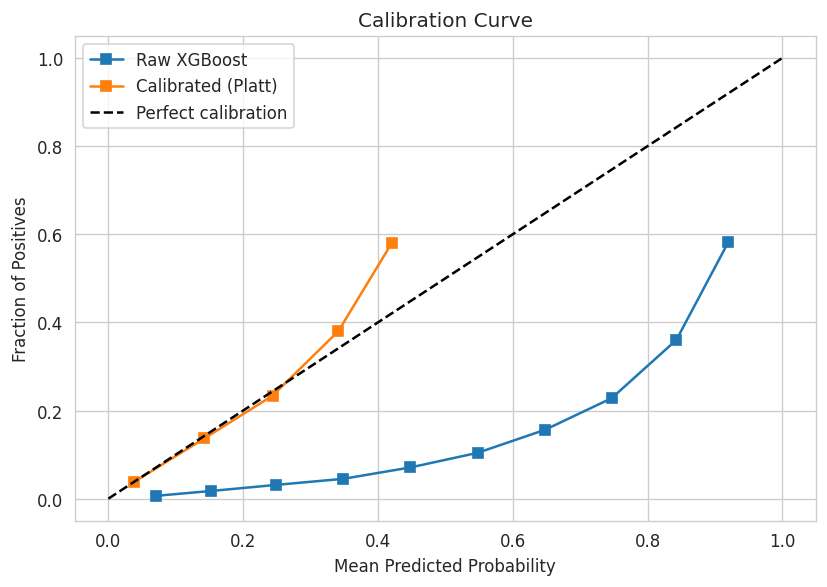


Using calibrated test probabilities for downstream evaluation.


In [17]:
# ── STEP 12: PROBABILITY CALIBRATION ───────────────────────
print("Calibrating model...")

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Use the chosen final model from Step 11
# Here we assume XGBoost is selected as the final model.
# Calibrate using CV on the training data only.
# -----------------------------------------------------------

# Fit a final uncalibrated model on train+val for comparison
# (this is okay because test is still untouched)
final_xgb_raw = XGBClassifier(**best_xgb_params)
final_xgb_raw.fit(X_train_full, y_train_full)

# Calibrate with cross-validation on the same training data
# This is safer than fitting on the test set
calibrated_model = CalibratedClassifierCV(
    estimator=final_xgb_raw,
    method="sigmoid",
    cv=3
)
calibrated_model.fit(X_train_full, y_train_full)

# Probabilities on test set
y_prob_raw_test = final_xgb_raw.predict_proba(X_test)[:, 1]
y_prob_cal_test = calibrated_model.predict_proba(X_test)[:, 1]

# Calibration quality
brier_raw = brier_score_loss(y_test, y_prob_raw_test)
brier_cal = brier_score_loss(y_test, y_prob_cal_test)

print(f"Brier Score — Raw:        {brier_raw:.4f}")
print(f"Brier Score — Calibrated: {brier_cal:.4f}")

if brier_raw > 0:
    print(f"Calibration improvement: {(brier_raw - brier_cal) / brier_raw:.1%}")

# Calibration plot
fig, ax = plt.subplots(figsize=(7, 5))

for label, probs in [
    ("Raw XGBoost", y_prob_raw_test),
    ("Calibrated (Platt)", y_prob_cal_test),
]:
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, fraction_pos, marker="s", label=label)

ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("plots/calibration_curve.png", dpi=150)
plt.show()

# Use calibrated probabilities for downstream test evaluation
y_prob_final = y_prob_cal_test.copy()

print("\nUsing calibrated test probabilities for downstream evaluation.")

## Step 13.A: Threshold Optimisation & Performance Metrics

A binary classifier requires a **decision threshold** to convert probabilities to accept/reject decisions. The default 0.5 threshold is rarely optimal for imbalanced credit datasets.

We evaluate three threshold selection methods:

1. **Youden's J statistic** (`sensitivity + specificity - 1`): maximises overall discriminatory power, balancing false accept and false reject rates equally. Used when both error types have similar costs.

2. **F1-score maximisation**: balances precision (of predicted defaults) and recall (% of true defaults caught). Used when catching defaults matters more than avoiding false alarms.

3. **Custom cost-based threshold**: weights the two error types by their actual business costs. In credit: the cost of a false negative (approving a defaulter) is typically 5–20× the cost of a false positive (rejecting a good borrower). Operational risk departments set this ratio.

**Regulatory context:** The threshold determines the **accept rate** and must be documented in the credit policy with justification (ECOA in the US, RBI Fair Practice Code in India).

Optimising thresholds on validation set...
Youden threshold : 0.4901
F1-best threshold : 0.5000
Cost-best threshold (chosen): 0.5000

Validation performance at chosen threshold:
Approval rate : 70.23%
Precision     : 0.1859
Recall        : 0.6855
F1            : 0.2925
Business cost : 21914
Confusion matrix: TN=33308, FP=11922, FN=1249, TP=2723

Validation ranking metrics — AUC: 0.7800 | Gini: 0.5600 | KS: 0.4240


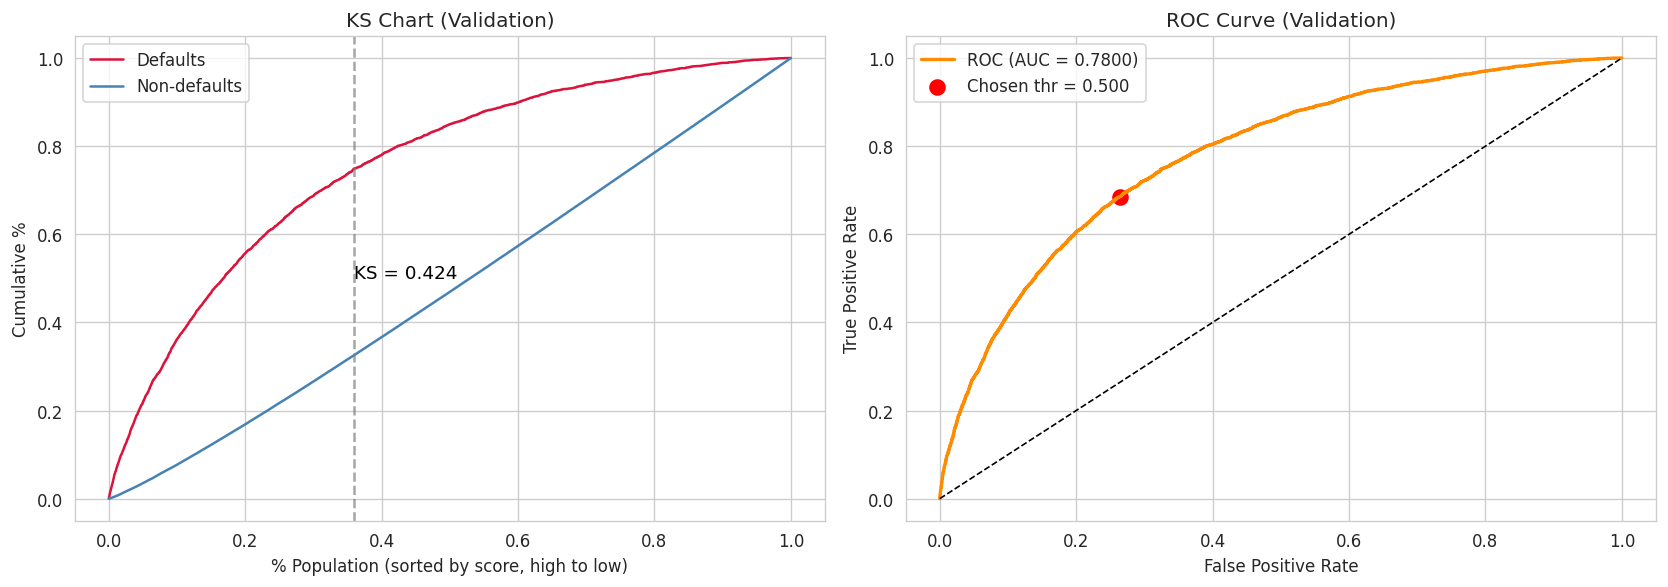


Final evaluation on TEST set using chosen validation threshold...
Test AUC  : 0.7858
Test Gini : 0.5715
Test KS   : 0.4309

Classification Report (Test, threshold = 0.500):
              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

Confusion Matrix (Test): TN=56538, FP=0, FN=4965, TP=0

Test threshold metrics:
Approval rate : 100.00%
Precision     : 0.0000
Recall        : 0.0000
F1            : 0.0000
Business cost : 39720


,chosen_threshold,val_auc,val_gini,val_ks,test_auc,test_gini,test_ks,test_precision,test_recall,test_f1,test_approval_rate,test_business_cost
0,0.5,0.780003,0.560006,0.423965,0.785762,0.571524,0.430947,0.0,0.0,0.0,1.0,39720.0


In [18]:
# ── STEP 13: THRESHOLD OPTIMISATION & PERFORMANCE METRICS ───
print("Optimising thresholds on validation set...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

# -----------------------------------------------------------
# Expected inputs from Step 12:
#   y_prob_val_final   -> calibrated validation probabilities
#   y_prob_test_final  -> calibrated test probabilities
#   y_val, y_test      -> true labels
# -----------------------------------------------------------

# If you only have one of these names, rename them accordingly.
# Example:
# y_prob_val_final = y_prob_cal_val
# y_prob_test_final = y_prob_cal_test

def ks_stat(y_true, y_prob):
    tmp = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p", ascending=False)
    tmp["cum_bad"] = tmp["y"].cumsum() / max(tmp["y"].sum(), 1)
    tmp["cum_good"] = (1 - tmp["y"]).cumsum() / max((1 - tmp["y"]).sum(), 1)
    return (tmp["cum_bad"] - tmp["cum_good"]).abs().max()

def gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def evaluate_threshold(y_true, y_prob, threshold, fp_cost=1.0, fn_cost=8.0):
    """
    fp_cost: cost of rejecting a good borrower
    fn_cost: cost of approving a bad borrower
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    tpr = recall
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    youden = tpr - fpr
    business_cost = fp_cost * fp + fn_cost * fn
    approval_rate = 1 - y_pred.mean()

    return {
        "threshold": threshold,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "fpr": fpr,
        "tpr": tpr,
        "f1": f1,
        "youden": youden,
        "business_cost": business_cost,
        "approval_rate": approval_rate,
    }

# -----------------------------------------------------------
# 1) Search thresholds on VALIDATION ONLY
# -----------------------------------------------------------
threshold_grid = np.linspace(0.01, 0.50, 100)

FP_COST = 1.0
FN_COST = 8.0   # adjust later if you want a different business assumption

val_results = []
for thr in threshold_grid:
    val_results.append(evaluate_threshold(y_val, y_prob_val_final, thr, fp_cost=FP_COST, fn_cost=FN_COST))

val_threshold_df = pd.DataFrame(val_results)

# Best thresholds under different criteria
thresh_youden = val_threshold_df.loc[val_threshold_df["youden"].idxmax(), "threshold"]
thresh_f1 = val_threshold_df.loc[val_threshold_df["f1"].idxmax(), "threshold"]
thresh_cost = val_threshold_df.loc[val_threshold_df["business_cost"].idxmin(), "threshold"]

print(f"Youden threshold : {thresh_youden:.4f}")
print(f"F1-best threshold : {thresh_f1:.4f}")
print(f"Cost-best threshold (chosen): {thresh_cost:.4f}")

# Summary at the chosen threshold on validation
val_best = val_threshold_df.loc[val_threshold_df["business_cost"].idxmin()].to_dict()

print("\nValidation performance at chosen threshold:")
print(f"Approval rate : {val_best['approval_rate']:.2%}")
print(f"Precision     : {val_best['precision']:.4f}")
print(f"Recall        : {val_best['recall']:.4f}")
print(f"F1            : {val_best['f1']:.4f}")
print(f"Business cost : {val_best['business_cost']:.0f}")
print(f"Confusion matrix: TN={int(val_best['tn'])}, FP={int(val_best['fp'])}, FN={int(val_best['fn'])}, TP={int(val_best['tp'])}")

# -----------------------------------------------------------
# 2) Ranking metrics on validation
# -----------------------------------------------------------
val_auc = roc_auc_score(y_val, y_prob_val_final)
val_gini = gini(y_val, y_prob_val_final)
val_ks = ks_stat(y_val, y_prob_val_final)

print(f"\nValidation ranking metrics — AUC: {val_auc:.4f} | Gini: {val_gini:.4f} | KS: {val_ks:.4f}")

# -----------------------------------------------------------
# 3) Plot KS and ROC on VALIDATION
# -----------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_val, y_prob_val_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KS plot
ax = axes[0]
df_ks_plot = pd.DataFrame({"y": y_val.values, "p": y_prob_val_final}).sort_values("p", ascending=False).reset_index(drop=True)
df_ks_plot["cum_bad"] = df_ks_plot["y"].cumsum() / max(df_ks_plot["y"].sum(), 1)
df_ks_plot["cum_good"] = (1 - df_ks_plot["y"]).cumsum() / max((1 - df_ks_plot["y"]).sum(), 1)
df_ks_plot["pct_pop"] = np.arange(1, len(df_ks_plot) + 1) / len(df_ks_plot)
df_ks_plot["ks_gap"] = (df_ks_plot["cum_bad"] - df_ks_plot["cum_good"]).abs()

ks_point = df_ks_plot["ks_gap"].idxmax()

ax.plot(df_ks_plot["pct_pop"], df_ks_plot["cum_bad"], label="Defaults", color="crimson")
ax.plot(df_ks_plot["pct_pop"], df_ks_plot["cum_good"], label="Non-defaults", color="steelblue")
ax.axvline(df_ks_plot.loc[ks_point, "pct_pop"], color="gray", linestyle="--", alpha=0.7)
ax.annotate(f"KS = {val_ks:.3f}",
            xy=(df_ks_plot.loc[ks_point, "pct_pop"], 0.5),
            fontsize=11, color="black")
ax.set_xlabel("% Population (sorted by score, high to low)")
ax.set_ylabel("Cumulative %")
ax.set_title("KS Chart (Validation)")
ax.legend()

# ROC plot
ax2 = axes[1]
chosen_point = evaluate_threshold(y_val, y_prob_val_final, thresh_cost, fp_cost=FP_COST, fn_cost=FN_COST)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {val_auc:.4f})")
ax2.plot([0, 1], [0, 1], "k--", lw=1)
ax2.scatter(chosen_point["fpr"], chosen_point["tpr"],
            marker="o", color="red", s=80, label=f"Chosen thr = {thresh_cost:.3f}")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve (Validation)")
ax2.legend()

plt.tight_layout()
plt.savefig("plots/ks_roc_curves.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# 4) Final TEST evaluation using the chosen validation threshold
# -----------------------------------------------------------
print("\nFinal evaluation on TEST set using chosen validation threshold...")

test_auc = roc_auc_score(y_test, y_prob_test_final)
test_gini = gini(y_test, y_prob_test_final)
test_ks = ks_stat(y_test, y_prob_test_final)

y_pred_test = (y_prob_test_final >= thresh_cost).astype(int)

print(f"Test AUC  : {test_auc:.4f}")
print(f"Test Gini : {test_gini:.4f}")
print(f"Test KS   : {test_ks:.4f}")

print(f"\nClassification Report (Test, threshold = {thresh_cost:.3f}):")
print(classification_report(y_test, y_pred_test, target_names=["Non-Default", "Default"]))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f"Confusion Matrix (Test): TN={tn}, FP={fp}, FN={fn}, TP={tp}")

test_precision = precision_score(y_test, y_pred_test, zero_division=0)
test_recall = recall_score(y_test, y_pred_test, zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, zero_division=0)
test_approval_rate = 1 - y_pred_test.mean()
test_business_cost = FP_COST * fp + FN_COST * fn

print(f"\nTest threshold metrics:")
print(f"Approval rate : {test_approval_rate:.2%}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1            : {test_f1:.4f}")
print(f"Business cost : {test_business_cost:.0f}")

# Save threshold summary if needed
threshold_summary = pd.DataFrame([{
    "chosen_threshold": thresh_cost,
    "val_auc": val_auc,
    "val_gini": val_gini,
    "val_ks": val_ks,
    "test_auc": test_auc,
    "test_gini": test_gini,
    "test_ks": test_ks,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_approval_rate": test_approval_rate,
    "test_business_cost": test_business_cost
}])

display(threshold_summary)

In [19]:
# Inspect probability distributions

print(np.quantile(y_prob_val_final, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print(np.quantile(y_prob_test_final, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

[0.00456057 0.11664217 0.19873492 0.34540322 0.54420444 0.71227267
 0.78995716 0.88328911]
[0.00905765 0.01554804 0.02284401 0.044547   0.10563756 0.2057704
 0.27398224 0.37577939]


## STEP 13.B: BUSINESS-PROFIT THRESHOLD OPTIMISATION

Optimising lending policy on validation set...

Business assumptions:
LGD                 : 45%
Net lending margin  : 10%
Operating cost rate : 1%

OPTIMAL VALIDATION LENDING POLICY
Optimal PD cutoff      : 0.6772
Approval rate          : 87.21%
Bad rate among approved: 5.33%

Approved exposure      : 26,263,384,893

Performing revenue     : 2,490,485,882
Default loss           : 611,336,731
Operating cost         : 262,633,849
------------------------------------------------------------
Portfolio profit       : 1,616,515,302
Return on exposure     : 6.16%


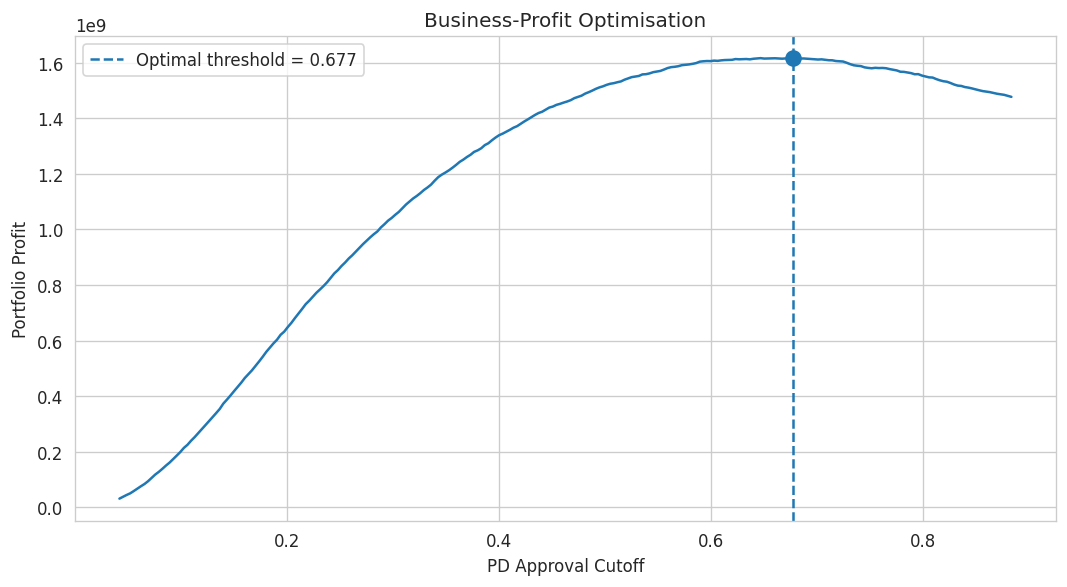

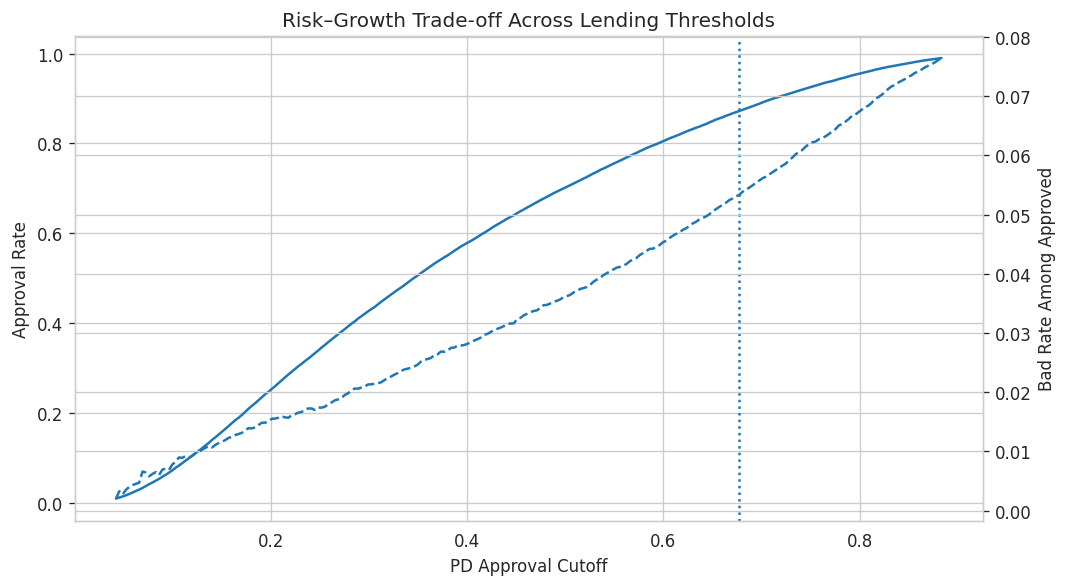


Evaluating frozen lending policy on TEST set...

FINAL TEST PORTFOLIO PERFORMANCE
Frozen PD cutoff       : 0.6772
Approval rate          : 100.00%
Bad rate among approved: 8.07%
Approved exposure      : 36,765,080,145
Performing revenue     : 3,398,972,243
Default loss           : 1,248,910,972
Operating cost         : 367,650,801
------------------------------------------------------------
Portfolio profit       : 1,782,410,470
Return on exposure     : 4.85%

Classification report at business-optimal threshold:

              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

Confusion matrix:
[[56538     0]
 [ 4965     0]]

Final model discrimination:
AUC  : 0.7858
Gini : 0.5715
KS   : 0.4309


In [21]:
# ── STEP 13: BUSINESS-PROFIT THRESHOLD OPTIMISATION ─────────
print("Optimising lending policy on validation set...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1. BUSINESS ASSUMPTIONS
# ============================================================

# Assumed proportion of exposure lost if a borrower defaults
LGD = 0.45

# Approximate net lending margin earned on a successfully
# performing loan.
#
# This is NOT the contractual interest rate.
# It represents a simplified portfolio-level revenue assumption.
NET_MARGIN = 0.10

# Optional origination / servicing cost as % of EAD
OPERATING_COST_RATE = 0.01


print("\nBusiness assumptions:")
print(f"LGD                 : {LGD:.0%}")
print(f"Net lending margin  : {NET_MARGIN:.0%}")
print(f"Operating cost rate : {OPERATING_COST_RATE:.0%}")


# ============================================================
# 2. GET EAD
# ============================================================

# Home Credit AMT_CREDIT is used as a proxy for Exposure at Default.
#
# IMPORTANT:
# X_val / X_test must still contain AMT_CREDIT after feature selection.
# If not, retrieve it separately from the corresponding original rows.

# if "AMT_CREDIT" not in X_val.columns:
#     raise ValueError(
#         "AMT_CREDIT is missing from X_val. "
#         "Keep AMT_CREDIT separately because it is needed for EAD."
#     )

# ead_val = X_val["AMT_CREDIT"].to_numpy()
# ead_test = X_test["AMT_CREDIT"].to_numpy()

ead_val = X_all.loc[X_val.index, "AMT_CREDIT"].to_numpy()
ead_test = X_all.loc[X_test.index, "AMT_CREDIT"].to_numpy()

# ============================================================
# 3. PORTFOLIO POLICY FUNCTION
# ============================================================

def evaluate_lending_policy(
    y_true,
    y_prob,
    ead,
    threshold,
    lgd=0.45,
    net_margin=0.10,
    operating_cost_rate=0.01
):
    """
    Evaluate a lending policy at a given PD cutoff.

    Decision:
        PD < threshold  -> APPROVE
        PD >= threshold -> REJECT

    Backtesting economics:
        Approved good borrower:
            profit = EAD * (net_margin - operating_cost_rate)

        Approved defaulting borrower:
            loss = EAD * LGD + EAD * operating_cost_rate

        Rejected borrower:
            profit = 0

    Returns portfolio-level business and risk metrics.
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ead = np.asarray(ead)

    approve = y_prob < threshold
    reject = ~approve

    approved_good = approve & (y_true == 0)
    approved_bad = approve & (y_true == 1)

    # --------------------------------------------------------
    # Revenue from performing approved loans
    # --------------------------------------------------------
    performing_revenue = (
        ead[approved_good] * net_margin
    ).sum()

    # --------------------------------------------------------
    # Operating cost on all originated loans
    # --------------------------------------------------------
    operating_cost = (
        ead[approve] * operating_cost_rate
    ).sum()

    # --------------------------------------------------------
    # Credit losses from approved defaults
    # --------------------------------------------------------
    default_loss = (
        ead[approved_bad] * lgd
    ).sum()

    # --------------------------------------------------------
    # Portfolio profit
    # --------------------------------------------------------
    portfolio_profit = (
        performing_revenue
        - default_loss
        - operating_cost
    )

    # --------------------------------------------------------
    # Portfolio metrics
    # --------------------------------------------------------
    total_applicants = len(y_true)
    approved_count = approve.sum()
    rejected_count = reject.sum()

    approval_rate = approved_count / total_applicants

    if approved_count > 0:
        bad_rate = y_true[approve].mean()
        approved_ead = ead[approve].sum()
    else:
        bad_rate = 0
        approved_ead = 0

    expected_loss_proxy = default_loss

    profit_per_applicant = portfolio_profit / total_applicants

    if approved_ead > 0:
        return_on_exposure = portfolio_profit / approved_ead
    else:
        return_on_exposure = 0

    return {
        "threshold": threshold,

        "approved_count": approved_count,
        "rejected_count": rejected_count,

        "approval_rate": approval_rate,
        "bad_rate": bad_rate,

        "approved_ead": approved_ead,

        "performing_revenue": performing_revenue,
        "operating_cost": operating_cost,
        "default_loss": default_loss,

        "portfolio_profit": portfolio_profit,
        "profit_per_applicant": profit_per_applicant,
        "return_on_exposure": return_on_exposure
    }


# ============================================================
# 4. THRESHOLD SEARCH — VALIDATION ONLY
# ============================================================

# Search across the actual probability range rather than assuming
# that useful thresholds occur near 0.50.

lower = max(0.001, np.quantile(y_prob_val_final, 0.01))
upper = min(0.999, np.quantile(y_prob_val_final, 0.99))

threshold_grid = np.linspace(
    lower,
    upper,
    250
)

policy_results = []

for threshold in threshold_grid:

    result = evaluate_lending_policy(
        y_true=y_val,
        y_prob=y_prob_val_final,
        ead=ead_val,
        threshold=threshold,
        lgd=LGD,
        net_margin=NET_MARGIN,
        operating_cost_rate=OPERATING_COST_RATE
    )

    policy_results.append(result)

policy_df = pd.DataFrame(policy_results)


# ============================================================
# 5. SELECT PROFIT-MAXIMISING THRESHOLD
# ============================================================

best_idx = policy_df["portfolio_profit"].idxmax()

best_policy = policy_df.loc[best_idx]

optimal_threshold = best_policy["threshold"]


print("\n" + "=" * 60)
print("OPTIMAL VALIDATION LENDING POLICY")
print("=" * 60)

print(f"Optimal PD cutoff      : {optimal_threshold:.4f}")
print(f"Approval rate          : {best_policy['approval_rate']:.2%}")
print(f"Bad rate among approved: {best_policy['bad_rate']:.2%}")

print(f"\nApproved exposure      : {best_policy['approved_ead']:,.0f}")

print(f"\nPerforming revenue     : {best_policy['performing_revenue']:,.0f}")
print(f"Default loss           : {best_policy['default_loss']:,.0f}")
print(f"Operating cost         : {best_policy['operating_cost']:,.0f}")

print("-" * 60)

print(
    f"Portfolio profit       : "
    f"{best_policy['portfolio_profit']:,.0f}"
)

print(
    f"Return on exposure     : "
    f"{best_policy['return_on_exposure']:.2%}"
)


# ============================================================
# 6. PLOT: PROFIT VS THRESHOLD
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    policy_df["threshold"],
    policy_df["portfolio_profit"]
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal threshold = {optimal_threshold:.3f}"
)

plt.scatter(
    optimal_threshold,
    best_policy["portfolio_profit"],
    s=80
)

plt.xlabel("PD Approval Cutoff")
plt.ylabel("Portfolio Profit")
plt.title("Business-Profit Optimisation")
plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/profit_vs_threshold.png",
    dpi=150
)

plt.show()


# ============================================================
# 7. PLOT: APPROVAL RATE AND BAD RATE
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    policy_df["threshold"],
    policy_df["approval_rate"],
    label="Approval Rate"
)

ax1.set_xlabel("PD Approval Cutoff")
ax1.set_ylabel("Approval Rate")

ax2 = ax1.twinx()

ax2.plot(
    policy_df["threshold"],
    policy_df["bad_rate"],
    linestyle="--",
    label="Bad Rate"
)

ax2.set_ylabel("Bad Rate Among Approved")

ax1.axvline(
    optimal_threshold,
    linestyle=":"
)

plt.title("Risk–Growth Trade-off Across Lending Thresholds")

fig.tight_layout()

plt.savefig(
    "plots/approval_bad_rate_tradeoff.png",
    dpi=150
)

plt.show()


# ============================================================
# 8. APPLY THE VALIDATION-SELECTED POLICY TO TEST SET
# ============================================================

print("\nEvaluating frozen lending policy on TEST set...")

test_policy = evaluate_lending_policy(
    y_true=y_test,
    y_prob=y_prob_test_final,
    ead=ead_test,
    threshold=optimal_threshold,
    lgd=LGD,
    net_margin=NET_MARGIN,
    operating_cost_rate=OPERATING_COST_RATE
)

print("\n" + "=" * 60)
print("FINAL TEST PORTFOLIO PERFORMANCE")
print("=" * 60)

print(f"Frozen PD cutoff       : {optimal_threshold:.4f}")

print(
    f"Approval rate          : "
    f"{test_policy['approval_rate']:.2%}"
)

print(
    f"Bad rate among approved: "
    f"{test_policy['bad_rate']:.2%}"
)

print(
    f"Approved exposure      : "
    f"{test_policy['approved_ead']:,.0f}"
)

print(
    f"Performing revenue     : "
    f"{test_policy['performing_revenue']:,.0f}"
)

print(
    f"Default loss           : "
    f"{test_policy['default_loss']:,.0f}"
)

print(
    f"Operating cost         : "
    f"{test_policy['operating_cost']:,.0f}"
)

print("-" * 60)

print(
    f"Portfolio profit       : "
    f"{test_policy['portfolio_profit']:,.0f}"
)

print(
    f"Return on exposure     : "
    f"{test_policy['return_on_exposure']:.2%}"
)


# ============================================================
# 9. CLASSIFICATION PERFORMANCE AT BUSINESS THRESHOLD
# ============================================================

# PD >= cutoff -> predicted default / reject
y_pred_test = (
    y_prob_test_final >= optimal_threshold
).astype(int)

print("\nClassification report at business-optimal threshold:\n")

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=[
            "Non-Default",
            "Default"
        ],
        zero_division=0
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_test
    )
)


# ============================================================
# 10. FINAL RANKING METRICS
# ============================================================

test_auc = roc_auc_score(
    y_test,
    y_prob_test_final
)

test_gini = 2 * test_auc - 1

test_ks = ks_stat(
    y_test,
    y_prob_test_final
)

print("\nFinal model discrimination:")

print(f"AUC  : {test_auc:.4f}")
print(f"Gini : {test_gini:.4f}")
print(f"KS   : {test_ks:.4f}")

## STEP 13.C: RISK-CONSTRAINED PROFIT OPTIMISATION

Optimising risk-constrained lending policy on validation set...

Business assumptions:
LGD                 : 45%
Net lending margin  : 10%
Operating cost rate : 1%
Review cost rate    : 0%

Risk constraints:
Min approval rate   : 50%
Max approval rate   : 85%
Max approved bad rate: 8%
Max review rate     : 20%
Review band width   : 0.050

OPTIMAL VALIDATION POLICY (feasible-profit-maximising)
Approve threshold      : 0.6468
Reject threshold       : 0.6968
Approval rate          : 84.68%
Review rate            : 4.09%
Reject rate             : 11.24%
Bad rate among approved: 5.01%

Approved exposure      : 25,613,238,694
Performing revenue     : 2,436,036,503
Default loss           : 563,793,147
Operating cost         : 256,132,387
Review cost            : 3,192,072
------------------------------------------------------------
Portfolio profit       : 1,612,918,897
Profit per applicant   : 32,781.57


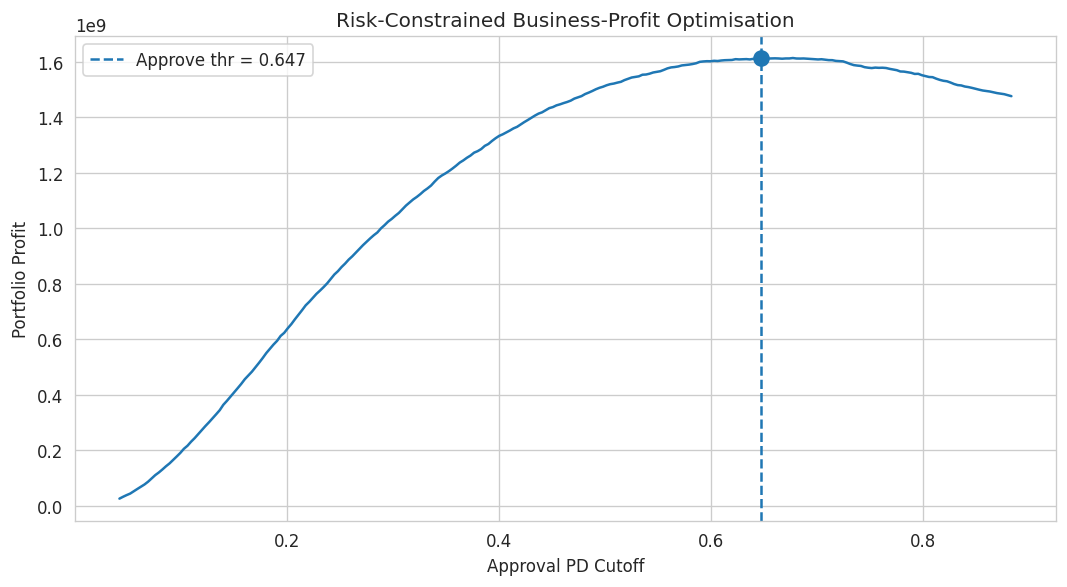

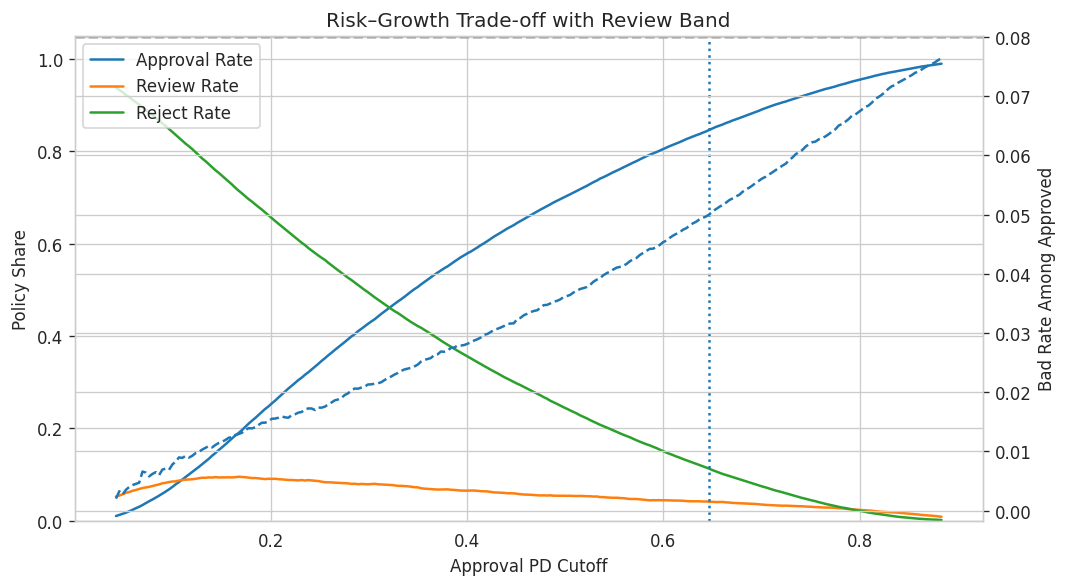


Evaluating frozen policy on TEST set...

FINAL TEST PORTFOLIO PERFORMANCE
Approve threshold      : 0.6468
Reject threshold       : 0.6968
Approval rate          : 100.00%
Review rate            : 0.00%
Reject rate             : 0.00%
Bad rate among approved: 8.07%

Approved exposure      : 36,765,080,145
Performing revenue     : 3,398,972,243
Default loss           : 1,248,910,972
Operating cost         : 367,650,801
Review cost            : 0
------------------------------------------------------------
Portfolio profit       : 1,782,410,470
Profit per applicant   : 28980.87

Binary report at approval cutoff (for reference only):

              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

Confusion matrix:
[[56538     0]


In [22]:
# ── STEP 13: RISK-CONSTRAINED PROFIT OPTIMISATION ──────────
print("Optimising risk-constrained lending policy on validation set...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# -----------------------------------------------------------
# IMPORTANT: use calibrated probabilities from the SAME model
# for both validation and test.
# -----------------------------------------------------------
# These should already exist from Step 12
# y_prob_val_final = calibrated_model.predict_proba(X_val)[:, 1]
# y_prob_test_final = calibrated_model.predict_proba(X_test)[:, 1]

# Exposure at Default
ead_val = ead_val if isinstance(ead_val, np.ndarray) else np.asarray(ead_val)
ead_test = ead_test if isinstance(ead_test, np.ndarray) else np.asarray(ead_test)

# -----------------------------------------------------------
# Business assumptions
# -----------------------------------------------------------
LGD = 0.45
NET_MARGIN = 0.10
OPERATING_COST_RATE = 0.01
REVIEW_COST_RATE = 0.003   # manual review cost on reviewed loans as % of EAD

# Risk appetite constraints
MIN_APPROVAL_RATE = 0.50
MAX_APPROVAL_RATE = 0.85
MAX_APPROVED_BAD_RATE = 0.08
MAX_REVIEW_RATE = 0.20

# Review band width around approval threshold
REVIEW_BAND = 0.05

print("\nBusiness assumptions:")
print(f"LGD                 : {LGD:.0%}")
print(f"Net lending margin  : {NET_MARGIN:.0%}")
print(f"Operating cost rate : {OPERATING_COST_RATE:.0%}")
print(f"Review cost rate    : {REVIEW_COST_RATE:.0%}")
print("\nRisk constraints:")
print(f"Min approval rate   : {MIN_APPROVAL_RATE:.0%}")
print(f"Max approval rate   : {MAX_APPROVAL_RATE:.0%}")
print(f"Max approved bad rate: {MAX_APPROVED_BAD_RATE:.0%}")
print(f"Max review rate     : {MAX_REVIEW_RATE:.0%}")
print(f"Review band width   : {REVIEW_BAND:.3f}")


def evaluate_triage_policy(
    y_true,
    y_prob,
    ead,
    approve_threshold,
    review_band=0.05,
    lgd=0.45,
    net_margin=0.10,
    operating_cost_rate=0.01,
    review_cost_rate=0.003
):
    """
    Triage policy:
        PD < approve_threshold                 -> APPROVE
        approve_threshold <= PD < reject_thr   -> REVIEW
        PD >= reject_thr                      -> REJECT

    Where reject_thr = approve_threshold + review_band.
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ead = np.asarray(ead)

    reject_threshold = min(0.999, approve_threshold + review_band)

    approve = y_prob < approve_threshold
    review = (y_prob >= approve_threshold) & (y_prob < reject_threshold)
    reject = y_prob >= reject_threshold

    approved_good = approve & (y_true == 0)
    approved_bad = approve & (y_true == 1)

    approved_count = approve.sum()
    review_count = review.sum()
    reject_count = reject.sum()
    total = len(y_true)

    approval_rate = approved_count / total
    review_rate = review_count / total
    reject_rate = reject_count / total

    bad_rate_approved = y_true[approve].mean() if approved_count > 0 else np.nan

    performing_revenue = (ead[approved_good] * net_margin).sum()
    default_loss = (ead[approved_bad] * lgd).sum()
    operating_cost = (ead[approve] * operating_cost_rate).sum()
    review_cost = (ead[review] * review_cost_rate).sum()

    portfolio_profit = performing_revenue - default_loss - operating_cost - review_cost
    profit_per_applicant = portfolio_profit / total
    approved_ead = ead[approve].sum()

    return {
        "approve_threshold": approve_threshold,
        "reject_threshold": reject_threshold,
        "approval_rate": approval_rate,
        "review_rate": review_rate,
        "reject_rate": reject_rate,
        "bad_rate_approved": bad_rate_approved,
        "approved_count": approved_count,
        "review_count": review_count,
        "reject_count": reject_count,
        "approved_ead": approved_ead,
        "performing_revenue": performing_revenue,
        "default_loss": default_loss,
        "operating_cost": operating_cost,
        "review_cost": review_cost,
        "portfolio_profit": portfolio_profit,
        "profit_per_applicant": profit_per_applicant,
    }


# -----------------------------------------------------------
# 1) Threshold search on VALIDATION only
# -----------------------------------------------------------
lower = max(0.001, np.quantile(y_prob_val_final, 0.01))
upper = min(0.999, np.quantile(y_prob_val_final, 0.99))

threshold_grid = np.linspace(lower, upper, 250)

rows = []
for thr in threshold_grid:
    res = evaluate_triage_policy(
        y_true=y_val,
        y_prob=y_prob_val_final,
        ead=ead_val,
        approve_threshold=thr,
        review_band=REVIEW_BAND,
        lgd=LGD,
        net_margin=NET_MARGIN,
        operating_cost_rate=OPERATING_COST_RATE,
        review_cost_rate=REVIEW_COST_RATE,
    )
    rows.append(res)

policy_df = pd.DataFrame(rows)

# Feasible region under risk constraints
feasible = policy_df[
    (policy_df["approval_rate"] >= MIN_APPROVAL_RATE) &
    (policy_df["approval_rate"] <= MAX_APPROVAL_RATE) &
    (policy_df["bad_rate_approved"] <= MAX_APPROVED_BAD_RATE) &
    (policy_df["review_rate"] <= MAX_REVIEW_RATE)
].copy()

if not feasible.empty:
    best_idx = feasible["portfolio_profit"].idxmax()
    selection_mode = "feasible-profit-maximising"
else:
    # Fallback: choose least-violating policy, then highest profit
    policy_df["violation"] = (
        np.maximum(0, MIN_APPROVAL_RATE - policy_df["approval_rate"]) +
        np.maximum(0, policy_df["approval_rate"] - MAX_APPROVAL_RATE) +
        np.maximum(0, policy_df["bad_rate_approved"] - MAX_APPROVED_BAD_RATE) +
        np.maximum(0, policy_df["review_rate"] - MAX_REVIEW_RATE)
    )
    best_idx = policy_df.sort_values(["violation", "portfolio_profit"], ascending=[True, False]).index[0]
    selection_mode = "least-violating fallback"

best_policy = policy_df.loc[best_idx]

print("\n" + "=" * 60)
print(f"OPTIMAL VALIDATION POLICY ({selection_mode})")
print("=" * 60)

print(f"Approve threshold      : {best_policy['approve_threshold']:.4f}")
print(f"Reject threshold       : {best_policy['reject_threshold']:.4f}")
print(f"Approval rate          : {best_policy['approval_rate']:.2%}")
print(f"Review rate            : {best_policy['review_rate']:.2%}")
print(f"Reject rate             : {best_policy['reject_rate']:.2%}")
print(f"Bad rate among approved: {best_policy['bad_rate_approved']:.2%}")

print(f"\nApproved exposure      : {best_policy['approved_ead']:,.0f}")
print(f"Performing revenue     : {best_policy['performing_revenue']:,.0f}")
print(f"Default loss           : {best_policy['default_loss']:,.0f}")
print(f"Operating cost         : {best_policy['operating_cost']:,.0f}")
print(f"Review cost            : {best_policy['review_cost']:,.0f}")
print("-" * 60)
print(f"Portfolio profit       : {best_policy['portfolio_profit']:,.0f}")
print(f"Profit per applicant   : {best_policy['profit_per_applicant']:,.2f}")

optimal_approve_threshold = float(best_policy["approve_threshold"])
optimal_reject_threshold = float(best_policy["reject_threshold"])


# -----------------------------------------------------------
# 2) Plot profit curve
# -----------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(policy_df["approve_threshold"], policy_df["portfolio_profit"])
plt.axvline(optimal_approve_threshold, linestyle="--", label=f"Approve thr = {optimal_approve_threshold:.3f}")
plt.scatter(optimal_approve_threshold, best_policy["portfolio_profit"], s=80)
plt.xlabel("Approval PD Cutoff")
plt.ylabel("Portfolio Profit")
plt.title("Risk-Constrained Business-Profit Optimisation")
plt.legend()
plt.tight_layout()
plt.savefig("plots/profit_vs_threshold_constrained.png", dpi=150)
plt.show()


# -----------------------------------------------------------
# 3) Plot approval / review / reject / bad-rate trade-off
# -----------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(policy_df["approve_threshold"], policy_df["approval_rate"], label="Approval Rate")
ax1.plot(policy_df["approve_threshold"], policy_df["review_rate"], label="Review Rate")
ax1.plot(policy_df["approve_threshold"], policy_df["reject_rate"], label="Reject Rate")
ax1.axvline(optimal_approve_threshold, linestyle=":")

ax1.set_xlabel("Approval PD Cutoff")
ax1.set_ylabel("Policy Share")
ax1.set_ylim(0, 1.05)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(policy_df["approve_threshold"], policy_df["bad_rate_approved"], linestyle="--", label="Bad Rate Among Approved")
ax2.axhline(MAX_APPROVED_BAD_RATE, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Bad Rate Among Approved")

plt.title("Risk–Growth Trade-off with Review Band")
fig.tight_layout()
plt.savefig("plots/risk_growth_tradeoff_constrained.png", dpi=150)
plt.show()


# -----------------------------------------------------------
# 4) Apply frozen policy to TEST set
# -----------------------------------------------------------
print("\nEvaluating frozen policy on TEST set...")

test_policy = evaluate_triage_policy(
    y_true=y_test,
    y_prob=y_prob_test_final,
    ead=ead_test,
    approve_threshold=optimal_approve_threshold,
    review_band=REVIEW_BAND,
    lgd=LGD,
    net_margin=NET_MARGIN,
    operating_cost_rate=OPERATING_COST_RATE,
    review_cost_rate=REVIEW_COST_RATE,
)

print("\n" + "=" * 60)
print("FINAL TEST PORTFOLIO PERFORMANCE")
print("=" * 60)

print(f"Approve threshold      : {optimal_approve_threshold:.4f}")
print(f"Reject threshold       : {optimal_reject_threshold:.4f}")
print(f"Approval rate          : {test_policy['approval_rate']:.2%}")
print(f"Review rate            : {test_policy['review_rate']:.2%}")
print(f"Reject rate             : {test_policy['reject_rate']:.2%}")
print(f"Bad rate among approved: {test_policy['bad_rate_approved']:.2%}")

print(f"\nApproved exposure      : {test_policy['approved_ead']:,.0f}")
print(f"Performing revenue     : {test_policy['performing_revenue']:,.0f}")
print(f"Default loss           : {test_policy['default_loss']:,.0f}")
print(f"Operating cost         : {test_policy['operating_cost']:,.0f}")
print(f"Review cost            : {test_policy['review_cost']:,.0f}")
print("-" * 60)
print(f"Portfolio profit       : {test_policy['portfolio_profit']:,.0f}")
print(f"Profit per applicant   : {test_policy['profit_per_applicant']:.2f}")


# -----------------------------------------------------------
# 5) Optional binary classification report for the approve cutoff
#    (Useful for reference, but the real policy is triage)
# -----------------------------------------------------------
y_pred_test_binary = (y_prob_test_final >= optimal_approve_threshold).astype(int)

print("\nBinary report at approval cutoff (for reference only):\n")
print(classification_report(
    y_test,
    y_pred_test_binary,
    target_names=["Non-Default", "Default"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_test_binary))


# -----------------------------------------------------------
# 6) Final discrimination metrics
# -----------------------------------------------------------
test_auc = roc_auc_score(y_test, y_prob_test_final)
test_gini = 2 * test_auc - 1

def ks_stat(y_true, y_prob):
    tmp = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p", ascending=False)
    tmp["cum_bad"] = tmp["y"].cumsum() / max(tmp["y"].sum(), 1)
    tmp["cum_good"] = (1 - tmp["y"]).cumsum() / max((1 - tmp["y"]).sum(), 1)
    return (tmp["cum_bad"] - tmp["cum_good"]).abs().max()

test_ks = ks_stat(y_test, y_prob_test_final)

print("\nFinal model discrimination:")
print(f"AUC  : {test_auc:.4f}")
print(f"Gini : {test_gini:.4f}")
print(f"KS   : {test_ks:.4f}")

## STEP 13.D: STRICT THRESHOLD RISK-CONSTRAINED PROFIT OPTIMISATION

Optimising risk-constrained lending policy on validation set...

Business assumptions:
LGD                 : 45%
Net lending margin  : 10%
Operating cost rate : 1%
Review cost rate    : 0%

Risk constraints:
Min approval rate   : 45%
Max approval rate   : 75%
Max approved bad rate: 6%
Max review rate     : 15%
Review band width   : 0.030

OPTIMAL VALIDATION POLICY (feasible-profit-maximising)
Approve threshold      : 0.5421
Reject threshold       : 0.5721
Approval rate          : 74.75%
Review rate            : 3.10%
Reject rate             : 22.15%
Bad rate among approved: 4.01%

Approved exposure      : 22,914,801,702
Performing revenue     : 2,200,378,352
Default loss           : 409,958,182
Operating cost         : 229,148,017
Review cost            : 2,539,844
------------------------------------------------------------
Portfolio profit       : 1,558,732,309
Profit per applicant   : 31,680.26


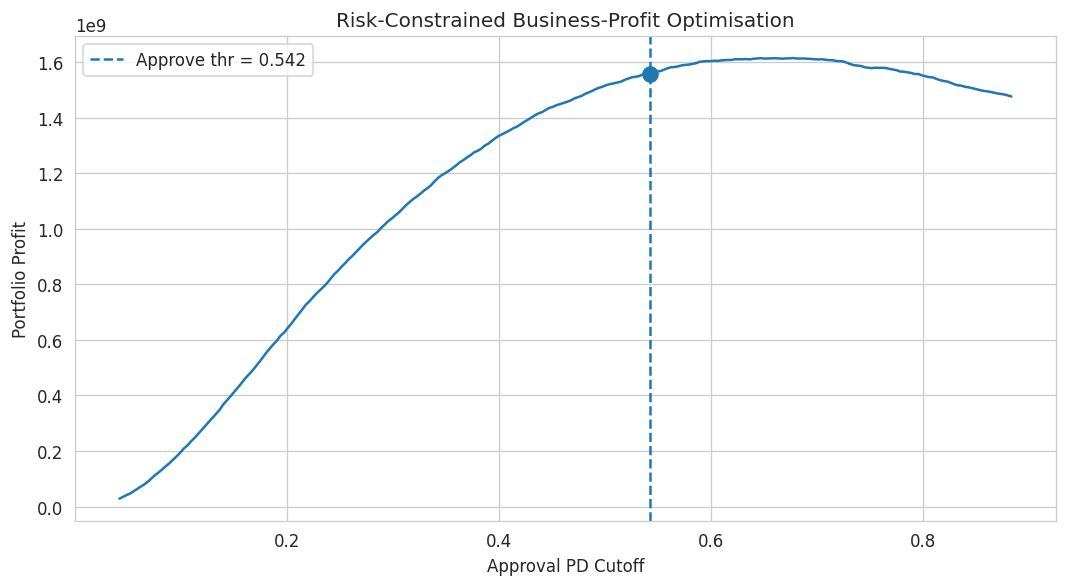

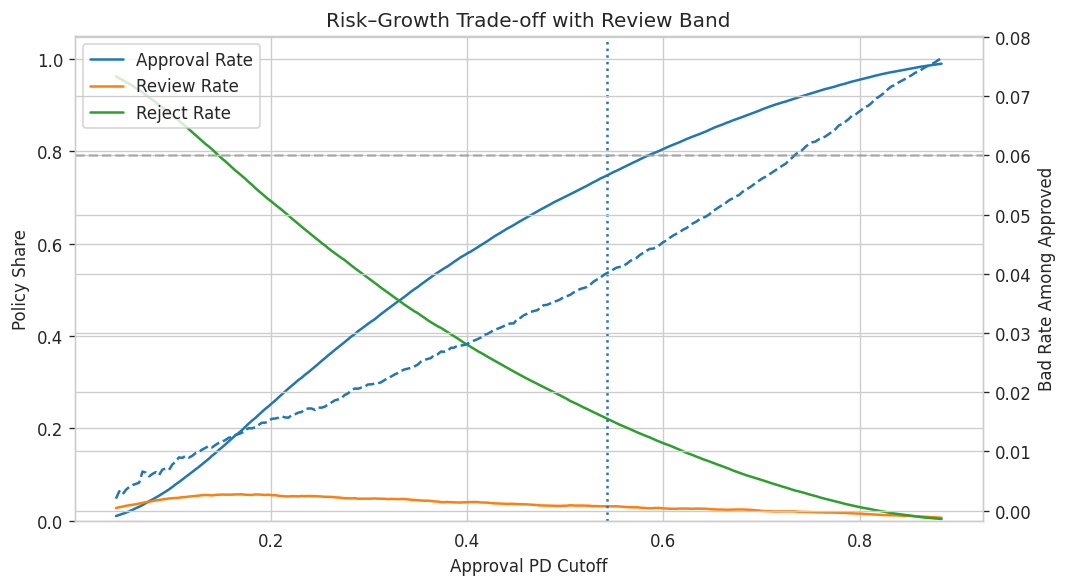


Evaluating frozen policy on TEST set...

FINAL TEST PORTFOLIO PERFORMANCE
Approve threshold      : 0.5421
Reject threshold       : 0.5721
Approval rate          : 100.00%
Review rate            : 0.00%
Reject rate             : 0.00%
Bad rate among approved: 8.07%

Approved exposure      : 36,765,080,145
Performing revenue     : 3,398,972,243
Default loss           : 1,248,910,972
Operating cost         : 367,650,801
Review cost            : 0
------------------------------------------------------------
Portfolio profit       : 1,782,410,470
Profit per applicant   : 28980.87

Binary report at approval cutoff (for reference only):

              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

Confusion matrix:
[[56538     0]


In [23]:
# ── STEP 13: RISK-CONSTRAINED PROFIT OPTIMISATION ──────────
print("Optimising risk-constrained lending policy on validation set...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# -----------------------------------------------------------
# IMPORTANT: use calibrated probabilities from the SAME model
# for both validation and test.
# -----------------------------------------------------------
# These should already exist from Step 12
# y_prob_val_final = calibrated_model.predict_proba(X_val)[:, 1]
# y_prob_test_final = calibrated_model.predict_proba(X_test)[:, 1]

# Exposure at Default
ead_val = ead_val if isinstance(ead_val, np.ndarray) else np.asarray(ead_val)
ead_test = ead_test if isinstance(ead_test, np.ndarray) else np.asarray(ead_test)

# -----------------------------------------------------------
# Business assumptions
# -----------------------------------------------------------
LGD = 0.45
NET_MARGIN = 0.10
OPERATING_COST_RATE = 0.01

# Make the constraints more stricter
# Risk appetite constraints
MIN_APPROVAL_RATE = 0.45
MAX_APPROVAL_RATE = 0.75
MAX_APPROVED_BAD_RATE = 0.06
MAX_REVIEW_RATE = 0.15
# Review band width around approval threshold
REVIEW_BAND = 0.03
# manual review cost on reviewed loans as % of EAD
REVIEW_COST_RATE = 0.003   

print("\nBusiness assumptions:")
print(f"LGD                 : {LGD:.0%}")
print(f"Net lending margin  : {NET_MARGIN:.0%}")
print(f"Operating cost rate : {OPERATING_COST_RATE:.0%}")
print(f"Review cost rate    : {REVIEW_COST_RATE:.0%}")
print("\nRisk constraints:")
print(f"Min approval rate   : {MIN_APPROVAL_RATE:.0%}")
print(f"Max approval rate   : {MAX_APPROVAL_RATE:.0%}")
print(f"Max approved bad rate: {MAX_APPROVED_BAD_RATE:.0%}")
print(f"Max review rate     : {MAX_REVIEW_RATE:.0%}")
print(f"Review band width   : {REVIEW_BAND:.3f}")


def evaluate_triage_policy(
    y_true,
    y_prob,
    ead,
    approve_threshold,
    review_band=0.05,
    lgd=0.45,
    net_margin=0.10,
    operating_cost_rate=0.01,
    review_cost_rate=0.003
):
    """
    Triage policy:
        PD < approve_threshold                 -> APPROVE
        approve_threshold <= PD < reject_thr   -> REVIEW
        PD >= reject_thr                      -> REJECT

    Where reject_thr = approve_threshold + review_band.
    """

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ead = np.asarray(ead)

    reject_threshold = min(0.999, approve_threshold + review_band)

    approve = y_prob < approve_threshold
    review = (y_prob >= approve_threshold) & (y_prob < reject_threshold)
    reject = y_prob >= reject_threshold

    approved_good = approve & (y_true == 0)
    approved_bad = approve & (y_true == 1)

    approved_count = approve.sum()
    review_count = review.sum()
    reject_count = reject.sum()
    total = len(y_true)

    approval_rate = approved_count / total
    review_rate = review_count / total
    reject_rate = reject_count / total

    bad_rate_approved = y_true[approve].mean() if approved_count > 0 else np.nan

    performing_revenue = (ead[approved_good] * net_margin).sum()
    default_loss = (ead[approved_bad] * lgd).sum()
    operating_cost = (ead[approve] * operating_cost_rate).sum()
    review_cost = (ead[review] * review_cost_rate).sum()

    portfolio_profit = performing_revenue - default_loss - operating_cost - review_cost
    profit_per_applicant = portfolio_profit / total
    approved_ead = ead[approve].sum()

    return {
        "approve_threshold": approve_threshold,
        "reject_threshold": reject_threshold,
        "approval_rate": approval_rate,
        "review_rate": review_rate,
        "reject_rate": reject_rate,
        "bad_rate_approved": bad_rate_approved,
        "approved_count": approved_count,
        "review_count": review_count,
        "reject_count": reject_count,
        "approved_ead": approved_ead,
        "performing_revenue": performing_revenue,
        "default_loss": default_loss,
        "operating_cost": operating_cost,
        "review_cost": review_cost,
        "portfolio_profit": portfolio_profit,
        "profit_per_applicant": profit_per_applicant,
    }


# -----------------------------------------------------------
# 1) Threshold search on VALIDATION only
# -----------------------------------------------------------
lower = max(0.001, np.quantile(y_prob_val_final, 0.01))
upper = min(0.999, np.quantile(y_prob_val_final, 0.99))

threshold_grid = np.linspace(lower, upper, 250)

rows = []
for thr in threshold_grid:
    res = evaluate_triage_policy(
        y_true=y_val,
        y_prob=y_prob_val_final,
        ead=ead_val,
        approve_threshold=thr,
        review_band=REVIEW_BAND,
        lgd=LGD,
        net_margin=NET_MARGIN,
        operating_cost_rate=OPERATING_COST_RATE,
        review_cost_rate=REVIEW_COST_RATE,
    )
    rows.append(res)

policy_df = pd.DataFrame(rows)

# Feasible region under risk constraints
feasible = policy_df[
    (policy_df["approval_rate"] >= MIN_APPROVAL_RATE) &
    (policy_df["approval_rate"] <= MAX_APPROVAL_RATE) &
    (policy_df["bad_rate_approved"] <= MAX_APPROVED_BAD_RATE) &
    (policy_df["review_rate"] <= MAX_REVIEW_RATE)
].copy()

if not feasible.empty:
    best_idx = feasible["portfolio_profit"].idxmax()
    selection_mode = "feasible-profit-maximising"
else:
    # Fallback: choose least-violating policy, then highest profit
    policy_df["violation"] = (
        np.maximum(0, MIN_APPROVAL_RATE - policy_df["approval_rate"]) +
        np.maximum(0, policy_df["approval_rate"] - MAX_APPROVAL_RATE) +
        np.maximum(0, policy_df["bad_rate_approved"] - MAX_APPROVED_BAD_RATE) +
        np.maximum(0, policy_df["review_rate"] - MAX_REVIEW_RATE)
    )
    best_idx = policy_df.sort_values(["violation", "portfolio_profit"], ascending=[True, False]).index[0]
    selection_mode = "least-violating fallback"

best_policy = policy_df.loc[best_idx]

print("\n" + "=" * 60)
print(f"OPTIMAL VALIDATION POLICY ({selection_mode})")
print("=" * 60)

print(f"Approve threshold      : {best_policy['approve_threshold']:.4f}")
print(f"Reject threshold       : {best_policy['reject_threshold']:.4f}")
print(f"Approval rate          : {best_policy['approval_rate']:.2%}")
print(f"Review rate            : {best_policy['review_rate']:.2%}")
print(f"Reject rate             : {best_policy['reject_rate']:.2%}")
print(f"Bad rate among approved: {best_policy['bad_rate_approved']:.2%}")

print(f"\nApproved exposure      : {best_policy['approved_ead']:,.0f}")
print(f"Performing revenue     : {best_policy['performing_revenue']:,.0f}")
print(f"Default loss           : {best_policy['default_loss']:,.0f}")
print(f"Operating cost         : {best_policy['operating_cost']:,.0f}")
print(f"Review cost            : {best_policy['review_cost']:,.0f}")
print("-" * 60)
print(f"Portfolio profit       : {best_policy['portfolio_profit']:,.0f}")
print(f"Profit per applicant   : {best_policy['profit_per_applicant']:,.2f}")

optimal_approve_threshold = float(best_policy["approve_threshold"])
optimal_reject_threshold = float(best_policy["reject_threshold"])


# -----------------------------------------------------------
# 2) Plot profit curve
# -----------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(policy_df["approve_threshold"], policy_df["portfolio_profit"])
plt.axvline(optimal_approve_threshold, linestyle="--", label=f"Approve thr = {optimal_approve_threshold:.3f}")
plt.scatter(optimal_approve_threshold, best_policy["portfolio_profit"], s=80)
plt.xlabel("Approval PD Cutoff")
plt.ylabel("Portfolio Profit")
plt.title("Risk-Constrained Business-Profit Optimisation")
plt.legend()
plt.tight_layout()
plt.savefig("plots/profit_vs_threshold_constrained.png", dpi=150)
plt.show()


# -----------------------------------------------------------
# 3) Plot approval / review / reject / bad-rate trade-off
# -----------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(policy_df["approve_threshold"], policy_df["approval_rate"], label="Approval Rate")
ax1.plot(policy_df["approve_threshold"], policy_df["review_rate"], label="Review Rate")
ax1.plot(policy_df["approve_threshold"], policy_df["reject_rate"], label="Reject Rate")
ax1.axvline(optimal_approve_threshold, linestyle=":")

ax1.set_xlabel("Approval PD Cutoff")
ax1.set_ylabel("Policy Share")
ax1.set_ylim(0, 1.05)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(policy_df["approve_threshold"], policy_df["bad_rate_approved"], linestyle="--", label="Bad Rate Among Approved")
ax2.axhline(MAX_APPROVED_BAD_RATE, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Bad Rate Among Approved")

plt.title("Risk–Growth Trade-off with Review Band")
fig.tight_layout()
plt.savefig("plots/risk_growth_tradeoff_constrained.png", dpi=150)
plt.show()


# -----------------------------------------------------------
# 4) Apply frozen policy to TEST set
# -----------------------------------------------------------
print("\nEvaluating frozen policy on TEST set...")

test_policy = evaluate_triage_policy(
    y_true=y_test,
    y_prob=y_prob_test_final,
    ead=ead_test,
    approve_threshold=optimal_approve_threshold,
    review_band=REVIEW_BAND,
    lgd=LGD,
    net_margin=NET_MARGIN,
    operating_cost_rate=OPERATING_COST_RATE,
    review_cost_rate=REVIEW_COST_RATE,
)

print("\n" + "=" * 60)
print("FINAL TEST PORTFOLIO PERFORMANCE")
print("=" * 60)

print(f"Approve threshold      : {optimal_approve_threshold:.4f}")
print(f"Reject threshold       : {optimal_reject_threshold:.4f}")
print(f"Approval rate          : {test_policy['approval_rate']:.2%}")
print(f"Review rate            : {test_policy['review_rate']:.2%}")
print(f"Reject rate             : {test_policy['reject_rate']:.2%}")
print(f"Bad rate among approved: {test_policy['bad_rate_approved']:.2%}")

print(f"\nApproved exposure      : {test_policy['approved_ead']:,.0f}")
print(f"Performing revenue     : {test_policy['performing_revenue']:,.0f}")
print(f"Default loss           : {test_policy['default_loss']:,.0f}")
print(f"Operating cost         : {test_policy['operating_cost']:,.0f}")
print(f"Review cost            : {test_policy['review_cost']:,.0f}")
print("-" * 60)
print(f"Portfolio profit       : {test_policy['portfolio_profit']:,.0f}")
print(f"Profit per applicant   : {test_policy['profit_per_applicant']:.2f}")


# -----------------------------------------------------------
# 5) Optional binary classification report for the approve cutoff
#    (Useful for reference, but the real policy is triage)
# -----------------------------------------------------------
y_pred_test_binary = (y_prob_test_final >= optimal_approve_threshold).astype(int)

print("\nBinary report at approval cutoff (for reference only):\n")
print(classification_report(
    y_test,
    y_pred_test_binary,
    target_names=["Non-Default", "Default"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_test_binary))


# -----------------------------------------------------------
# 6) Final discrimination metrics
# -----------------------------------------------------------
test_auc = roc_auc_score(y_test, y_prob_test_final)
test_gini = 2 * test_auc - 1

def ks_stat(y_true, y_prob):
    tmp = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p", ascending=False)
    tmp["cum_bad"] = tmp["y"].cumsum() / max(tmp["y"].sum(), 1)
    tmp["cum_good"] = (1 - tmp["y"]).cumsum() / max((1 - tmp["y"]).sum(), 1)
    return (tmp["cum_bad"] - tmp["cum_good"]).abs().max()

test_ks = ks_stat(y_test, y_prob_test_final)

print("\nFinal model discrimination:")
print(f"AUC  : {test_auc:.4f}")
print(f"Gini : {test_gini:.4f}")
print(f"KS   : {test_ks:.4f}")

## Step 14: FICO-Style Credit Scorecard

A **FICO scorecard** translates the model's predicted PD into a human-interpretable integer score. The standard FICO range is **300–850** (higher = lower risk, better creditworthiness).

**Score-to-PD mapping** (log-odds scaling):
$$\text{Score} = \text{Base Score} - \text{PDO} \times \log_2\left(\frac{PD}{1 - PD}\right)$$

Where **PDO** (Points to Double the Odds) is typically 20–40 points. A PDO of 20 means each 20-point increase in score halves the odds of default.

**Grade bands** (regulatory and product tiers):

| Grade | Score | Risk Level | Typical Pricing |
|-------|-------|------------|----------------|
| A | 750–850 | Very Low | Prime rate |
| B | 650–749 | Low | Prime + spread |
| C | 550–649 | Medium | Risk-adjusted |
| D | 450–549 | High | Sub-prime / collateral required |
| E | 300–449 | Very High | Decline or secured only |

**Regulatory context:** Basel II Standardised Approach and IRB both require that internal rating grades be monotonically ordered by PD. FICO-style scores ensure this monotonicity.

# Risk Bands: Use business-rule PD bands rather than score bands.
A good starting policy is:
- Very Low Risk: PD < 3%
- Low Risk: 3%–7%
- Moderate Risk: 7%–15%
- High Risk: 15%–30%
- Very High Risk: PD ≥ 30%

Creating risk bands...

Validation risk band distribution:
     Risk_Band  Count   Avg_PD  Default_Rate Approval_Style
 Very Low Risk    200 0.021755      0.000000        Approve
      Low Risk   1511 0.053375      0.007280        Approve
 Moderate Risk   6082 0.113214      0.013154         Review
     High Risk  13260 0.223026      0.026923         Reject
Very High Risk  28149 0.535372      0.125191         Reject

Test risk band distribution:
     Risk_Band  Count   Avg_PD  Default_Rate Approval_Style
 Very Low Risk  21950 0.019526      0.018679        Approve
      Low Risk  17515 0.046305      0.046760        Approve
 Moderate Risk  11738 0.103269      0.101465         Review
     High Risk   8063 0.210875      0.201910         Reject
Very High Risk   2237 0.353024      0.409924         Reject


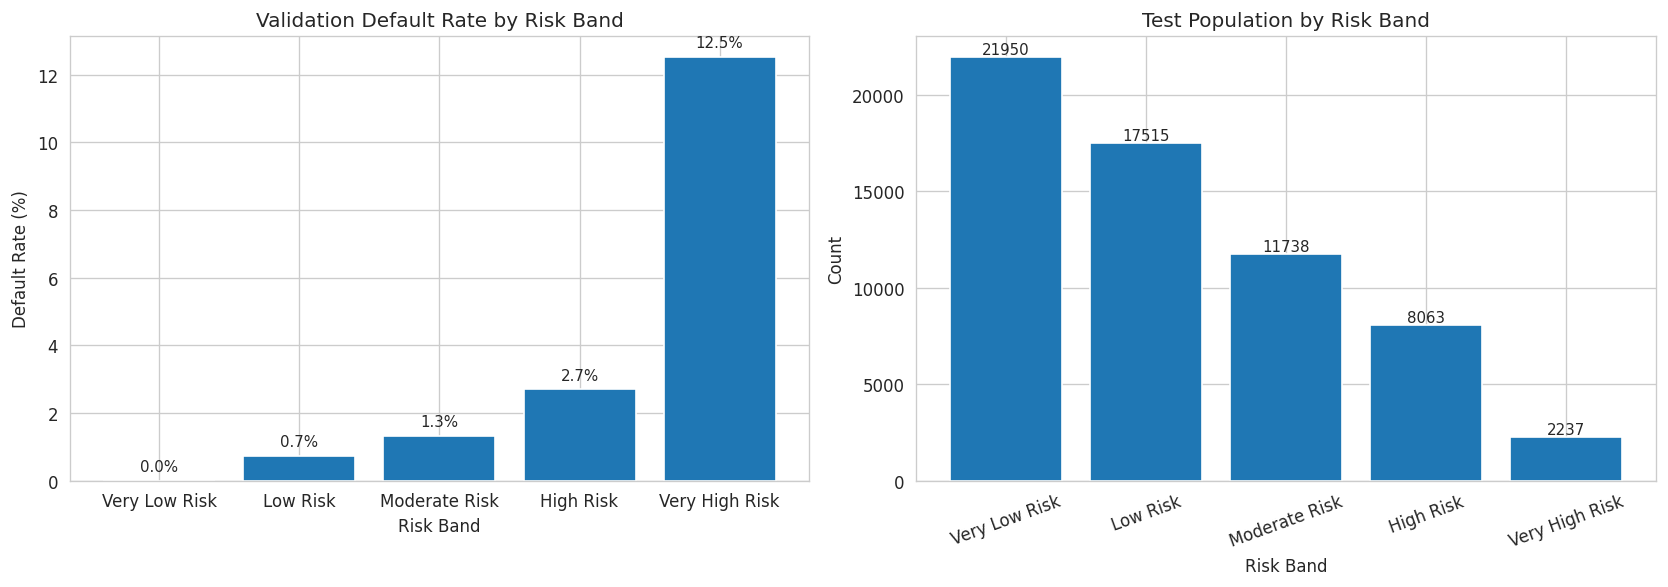


Risk bands created successfully.


In [24]:
# ── STEP 14: RISK BANDS ─────────────────────────────────────
print("Creating risk bands...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use calibrated probabilities
# y_prob_val_final and y_prob_test_final should already exist
# from Step 12 / Step 13

# -----------------------------------------------------------
# 1) Define PD band cutoffs
# -----------------------------------------------------------
band_edges = [0.00, 0.03, 0.07, 0.15, 0.30, 1.00]
band_labels = [
    "Very Low Risk",
    "Low Risk",
    "Moderate Risk",
    "High Risk",
    "Very High Risk"
]

def assign_risk_band(pd_val):
    return pd.cut(
        pd.Series(pd_val),
        bins=band_edges,
        labels=band_labels,
        include_lowest=True,
        right=False
    )

def recommended_action(band):
    if band in ["Very Low Risk", "Low Risk"]:
        return "Approve"
    elif band == "Moderate Risk":
        return "Review"
    else:
        return "Reject"

# -----------------------------------------------------------
# 2) Build validation and test band tables
# -----------------------------------------------------------
risk_val = pd.DataFrame({
    "PD": y_prob_val_final,
    "Actual": y_val.values
})
risk_val["Risk_Band"] = assign_risk_band(risk_val["PD"])
risk_val["Recommended_Action"] = risk_val["Risk_Band"].apply(recommended_action)

risk_test = pd.DataFrame({
    "PD": y_prob_test_final,
    "Actual": y_test.values
})
risk_test["Risk_Band"] = assign_risk_band(risk_test["PD"])
risk_test["Recommended_Action"] = risk_test["Risk_Band"].apply(recommended_action)

# -----------------------------------------------------------
# 3) Band summary function
# -----------------------------------------------------------
def band_summary(df):
    summary = df.groupby("Risk_Band", observed=False).agg(
        Count=("PD", "count"),
        Avg_PD=("PD", "mean"),
        Default_Rate=("Actual", "mean")
    ).reindex(band_labels)
    summary["Approval_Style"] = [
        "Approve", "Approve", "Review", "Reject", "Reject"
    ]
    return summary.reset_index()

val_band_summary = band_summary(risk_val)
test_band_summary = band_summary(risk_test)

print("\nValidation risk band distribution:")
print(val_band_summary.to_string(index=False))

print("\nTest risk band distribution:")
print(test_band_summary.to_string(index=False))

# -----------------------------------------------------------
# 4) Plot: validation default rate by band
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(
    val_band_summary["Risk_Band"].astype(str),
    val_band_summary["Default_Rate"] * 100
)
ax.set_xlabel("Risk Band")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Validation Default Rate by Risk Band")
for bar, val in zip(bars, val_band_summary["Default_Rate"] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20)

# Plot: band counts
ax2 = axes[1]
bars2 = ax2.bar(
    test_band_summary["Risk_Band"].astype(str),
    test_band_summary["Count"]
)
ax2.set_xlabel("Risk Band")
ax2.set_ylabel("Count")
ax2.set_title("Test Population by Risk Band")
for bar, val in zip(bars2, test_band_summary["Count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{int(val)}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("plots/risk_bands.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# 5) Optional: keep a compact summary for downstream use
# -----------------------------------------------------------
risk_band_map = {
    "Very Low Risk": "Approve",
    "Low Risk": "Approve",
    "Moderate Risk": "Review",
    "High Risk": "Reject",
    "Very High Risk": "Reject"
}

risk_val["Final_Decision"] = risk_val["Risk_Band"].map(risk_band_map)
risk_test["Final_Decision"] = risk_test["Risk_Band"].map(risk_band_map)

print("\nRisk bands created successfully.")

## Step 15: ECL ENGINE (SIMPLIFIED IFRS 9-STYLE)

Computing ECL under scenario assumptions...

ECL Summary by Stage:
 Stage  Count   Avg_PD       Avg_EAD    Total_EAD      ECL_Low     ECL_Base   ECL_Stress  Coverage_Low  Coverage_Base  Coverage_Stress
     1  39465 0.031411 624328.908552 2.463914e+10 2.692663e+08 3.461995e+08 4.615994e+08      0.010928       0.014051         0.018734
     2  11738 0.103269 575597.893679 6.756368e+09 6.538524e+08 8.406674e+08 1.120890e+09      0.096776       0.124426         0.165901
     3  10300 0.241748 521317.640097 5.369572e+09 1.029037e+09 1.323047e+09 1.764063e+09      0.191642       0.246397         0.328530

Total ECL (Low LGD)   : 1,952,155,512
Total ECL (Base LGD)  : 2,509,914,230
Total ECL (Stress LGD): 3,346,552,306
Total EAD             : 36,765,080,145

ECL Summary by Risk Band:
     Risk_Band  Count   Avg_PD  Default_Rate    Total_EAD     ECL_Base
 Very Low Risk  21950 0.019526      0.018679 1.380897e+10 1.213584e+08
      Low Risk  17515 0.046305      0.046760 1.083017e+10 2.248412e+08

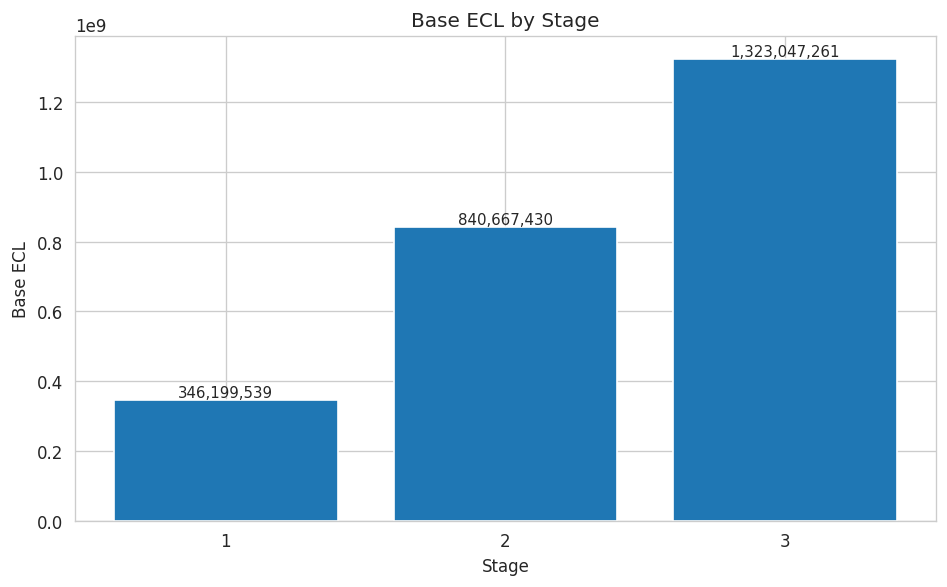

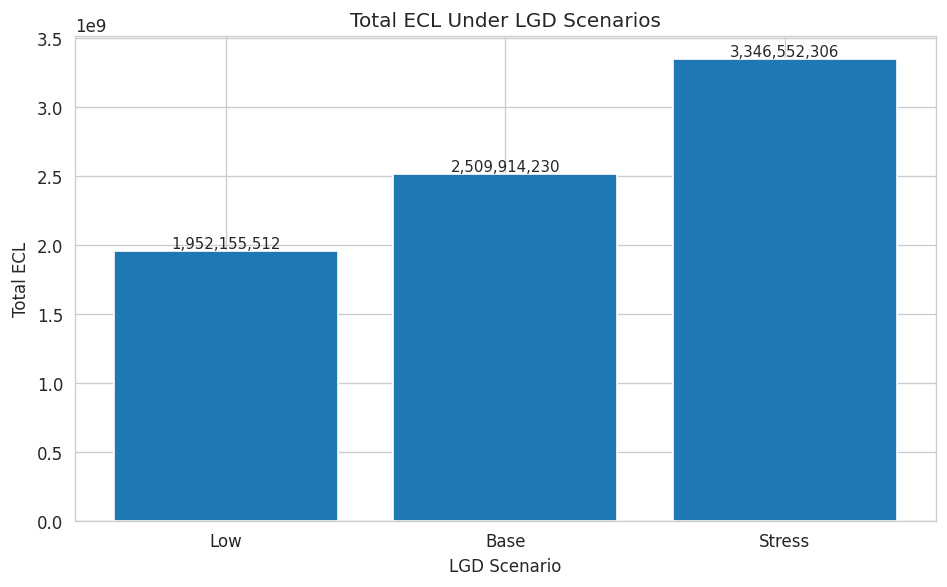


ECL engine completed successfully.


In [25]:
# ── STEP 15: ECL ENGINE (SIMPLIFIED IFRS 9-STYLE) ─────────
print("Computing ECL under scenario assumptions...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Inputs expected from previous steps:
#   y_prob_test_final  -> calibrated PD on test set
#   y_test             -> actual outcomes
#   ead_test           -> exposure at default proxy (AMT_CREDIT)
#   band_edges         -> from Step 14
#   band_labels        -> from Step 14
# -----------------------------------------------------------

TENOR_YEARS = 3

LGD_SCENARIOS = {
    "Low": 0.35,
    "Base": 0.45,
    "Stress": 0.60
}

# Risk-band-to-stage proxy for this project
stage_map = {
    "Very Low Risk": 1,
    "Low Risk": 1,
    "Moderate Risk": 2,
    "High Risk": 3,
    "Very High Risk": 3
}

# -----------------------------------------------------------
# Build ECL table
# -----------------------------------------------------------
ecl_test = pd.DataFrame({
    "PD": np.asarray(y_prob_test_final),
    "EAD": np.asarray(ead_test),
    "Actual": np.asarray(y_test),
})

ecl_test["Risk_Band"] = pd.cut(
    ecl_test["PD"],
    bins=band_edges,
    labels=band_labels,
    include_lowest=True,
    right=False
)

ecl_test["Stage"] = ecl_test["Risk_Band"].map(stage_map)

def calculate_lifetime_pd(pd_values, stage_values, tenor_years=3):
    pd_values = np.asarray(pd_values)
    stage_values = np.asarray(stage_values)
    return np.where(
        stage_values == 1,
        pd_values,
        1 - (1 - pd_values) ** tenor_years
    )

ecl_test["Lifetime_PD"] = calculate_lifetime_pd(
    ecl_test["PD"],
    ecl_test["Stage"],
    TENOR_YEARS
)

# Scenario ECLs
for scenario_name, lgd_value in LGD_SCENARIOS.items():
    ecl_test[f"ECL_{scenario_name}"] = ecl_test["Lifetime_PD"] * lgd_value * ecl_test["EAD"]

# -----------------------------------------------------------
# Summaries by stage
# -----------------------------------------------------------
stage_summary = ecl_test.groupby("Stage").agg(
    Count=("PD", "count"),
    Avg_PD=("PD", "mean"),
    Avg_EAD=("EAD", "mean"),
    Total_EAD=("EAD", "sum"),
    ECL_Low=("ECL_Low", "sum"),
    ECL_Base=("ECL_Base", "sum"),
    ECL_Stress=("ECL_Stress", "sum"),
).reset_index()

stage_summary["Coverage_Low"] = stage_summary["ECL_Low"] / stage_summary["Total_EAD"]
stage_summary["Coverage_Base"] = stage_summary["ECL_Base"] / stage_summary["Total_EAD"]
stage_summary["Coverage_Stress"] = stage_summary["ECL_Stress"] / stage_summary["Total_EAD"]

print("\nECL Summary by Stage:")
print(stage_summary.to_string(index=False))

print(f"\nTotal ECL (Low LGD)   : {ecl_test['ECL_Low'].sum():,.0f}")
print(f"Total ECL (Base LGD)  : {ecl_test['ECL_Base'].sum():,.0f}")
print(f"Total ECL (Stress LGD): {ecl_test['ECL_Stress'].sum():,.0f}")
print(f"Total EAD             : {ecl_test['EAD'].sum():,.0f}")

# -----------------------------------------------------------
# Summaries by risk band
# -----------------------------------------------------------
band_summary = ecl_test.groupby("Risk_Band", observed=False).agg(
    Count=("PD", "count"),
    Avg_PD=("PD", "mean"),
    Default_Rate=("Actual", "mean"),
    Total_EAD=("EAD", "sum"),
    ECL_Base=("ECL_Base", "sum"),
).reindex(band_labels).reset_index()

print("\nECL Summary by Risk Band:")
print(band_summary.to_string(index=False))

# -----------------------------------------------------------
# Plots
# -----------------------------------------------------------

# 1) Base ECL by stage
plt.figure(figsize=(8, 5))
plt.bar(stage_summary["Stage"].astype(str), stage_summary["ECL_Base"])
plt.xlabel("Stage")
plt.ylabel("Base ECL")
plt.title("Base ECL by Stage")
for x, y in zip(stage_summary["Stage"].astype(str), stage_summary["ECL_Base"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("plots/ecl_by_stage.png", dpi=150)
plt.show()

# 2) Scenario comparison
scenario_totals = pd.Series({
    "Low": ecl_test["ECL_Low"].sum(),
    "Base": ecl_test["ECL_Base"].sum(),
    "Stress": ecl_test["ECL_Stress"].sum()
})

plt.figure(figsize=(8, 5))
bars = plt.bar(scenario_totals.index, scenario_totals.values)
plt.xlabel("LGD Scenario")
plt.ylabel("Total ECL")
plt.title("Total ECL Under LGD Scenarios")
for bar, val in zip(bars, scenario_totals.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:,.0f}",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("plots/ecl_scenarios.png", dpi=150)
plt.show()

print("\nECL engine completed successfully.")

## Step 16: Population Stability Index (PSI): Production Monitoring

**PSI measures how much a model's score distribution has shifted** between the training population and a monitoring population (e.g., new applications in the most recent month).

$$\text{PSI} = \sum_{i=1}^{n} (A_i - E_i) \times \ln\left(\frac{A_i}{E_i}\right)$$

where $A_i$ = actual proportion in bin $i$, $E_i$ = expected proportion in bin $i$.

**PSI thresholds (industry standard):**

| PSI | Interpretation | Action |
|-----|---------------|--------|
| < 0.10 | Stable | No action required |
| 0.10 – 0.20 | Slight drift | Monitor closely, investigate |
| > 0.20 | **Significant shift** | **Redevelop or recalibrate model** |

**Production monitoring context:**
- Computed monthly as part of model performance monitoring (MPM) under Basel IRB/SR 11-7
- PSI > 0.20 triggers a model review and potential scorecard redevelopment
- Feature-level PSI (CSI- Characteristic Stability Index) identifies WHICH features are drifting

Computing PSI...

PSI Score: 5.5261  --  Significant shift (>0.20)

PSI by bin:
           Bin  Expected_Count  Actual_Count  Expected_Pct  Actual_Pct  PSI_Contribution
 (-inf, 0.117]            4921         47648      0.100016    0.774726          1.381251
(0.117, 0.172]            4920          5399      0.099996    0.087784          0.001591
(0.172, 0.226]            4920          3383      0.099996    0.055005          0.026891
(0.226, 0.283]            4920          2298      0.099996    0.037364          0.061656
(0.283, 0.345]            4920          1656      0.099996    0.026926          0.095872
(0.345, 0.416]            4920           945      0.099996    0.015365          0.158516
(0.416, 0.498]            4920           174      0.099996    0.002829          0.346415
(0.498, 0.594]            4920             0      0.099996    0.000001          1.151230
(0.594, 0.712]            4920             0      0.099996    0.000001          1.151230
  (0.712, inf]            4921

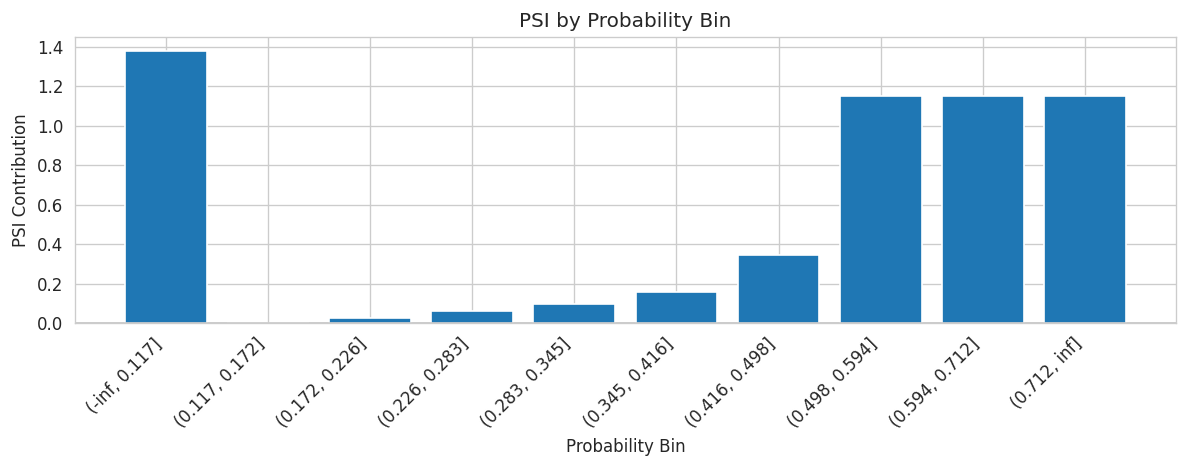

Plot saved: plots/psi_by_bin.png


In [26]:
# ── STEP 16: POPULATION STABILITY INDEX (PSI) ───────────────
print("Computing PSI...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Use calibrated probabilities consistently
# Expected / reference population:
#   y_prob_val_final
# Monitored population:
#   y_prob_test_final
# -----------------------------------------------------------

expected = pd.Series(np.asarray(y_prob_val_final), name="Expected")
actual = pd.Series(np.asarray(y_prob_test_final), name="Actual")


def compute_psi(expected, actual, n_bins=10, eps=1e-6):
    """
    PSI using bins defined from the expected distribution.
    Returns:
        psi_total: overall PSI
        psi_table: bin-level summary dataframe
    """

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # Use quantiles of the expected distribution to define bins
    quantiles = np.linspace(0, 1, n_bins + 1)
    breakpoints = expected.quantile(quantiles).values

    # Remove duplicate bin edges if score distribution is narrow
    breakpoints = np.unique(breakpoints)

    # If too few unique breakpoints, fall back to equal-width bins on expected range
    if len(breakpoints) < 3:
        breakpoints = np.linspace(expected.min(), expected.max(), n_bins + 1)
        breakpoints = np.unique(breakpoints)

    # Make sure the first and last edges fully cover the range
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    exp_counts = expected_bins.value_counts().sort_index()
    act_counts = actual_bins.value_counts().sort_index()

    exp_pct = exp_counts / len(expected)
    act_pct = act_counts / len(actual)

    # Avoid divide-by-zero
    exp_pct = exp_pct.replace(0, eps)
    act_pct = act_pct.replace(0, eps)

    psi_values = (act_pct - exp_pct) * np.log(act_pct / exp_pct)

    psi_table = pd.DataFrame({
        "Bin": exp_pct.index.astype(str),
        "Expected_Count": exp_counts.values,
        "Actual_Count": act_counts.values,
        "Expected_Pct": exp_pct.values,
        "Actual_Pct": act_pct.values,
        "PSI_Contribution": psi_values.values
    })

    psi_total = psi_values.sum()
    return psi_total, psi_table


psi_score, psi_table = compute_psi(expected, actual, n_bins=10)

if psi_score < 0.10:
    psi_label = "Stable (<0.10)"
elif psi_score < 0.20:
    psi_label = "Slight drift (0.10–0.20)"
else:
    psi_label = "Significant shift (>0.20)"

print(f"\nPSI Score: {psi_score:.4f}  --  {psi_label}")

print("\nPSI by bin:")
print(psi_table.to_string(index=False))

# -----------------------------------------------------------
# Plot PSI contributions
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(psi_table["Bin"], psi_table["PSI_Contribution"], edgecolor="white")
ax.set_title("PSI by Probability Bin")
ax.set_xlabel("Probability Bin")
ax.set_ylabel("PSI Contribution")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plots/psi_by_bin.png", dpi=150)
plt.show()

print("Plot saved: plots/psi_by_bin.png")

# STEP 17: STRESS TESTING MACRO SCENARIOS

- Normal
- Mild recession
- Severe recession  

## Under each scenario, changes the threshold:  

- increase PD,
- increase LGD,
- reduce lending margin,
- optionally increase operating cost,
- and then observe how:
  - approval rate changes,
  - review/reject shares change,
  - stage migration changes,
  - ECL changes,
  - expected portfolio profit changes.

Running portfolio stress scenarios...

Stress Test Results:
        Scenario  Approval_Rate  Review_Rate  Reject_Rate  Avg_Stressed_PD  Stage1_%  Stage2_%  Stage3_%    Total_ECL  ECL_Coverage  Expected_Profit
          Normal       1.000000     0.000000     0.000000         0.080350  0.641676  0.190852  0.167472 2.509914e+09      0.068269     1.799034e+09
  Mild Recession       0.999772     0.000211     0.000016         0.096421  0.587012  0.204088  0.208900 3.364050e+09      0.091501     5.910619e+08
Severe Recession       0.986488     0.004634     0.008878         0.120526  0.515487  0.221339  0.263174 5.008665e+09      0.136234    -9.294266e+08

Profit uplift vs Normal:
        Scenario  Profit_Uplift_vs_Normal
          Normal                 0.000000
  Mild Recession                -0.671456
Severe Recession                -1.516625


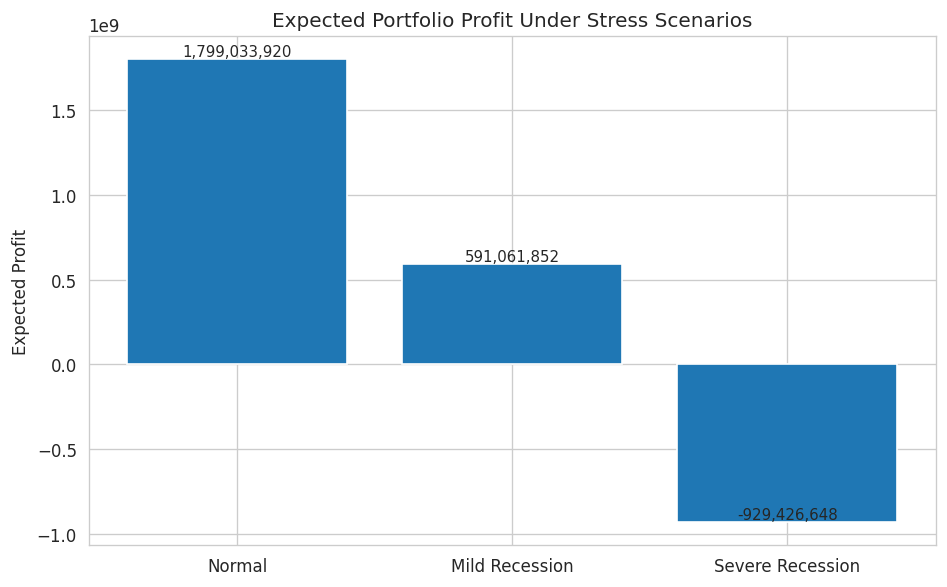

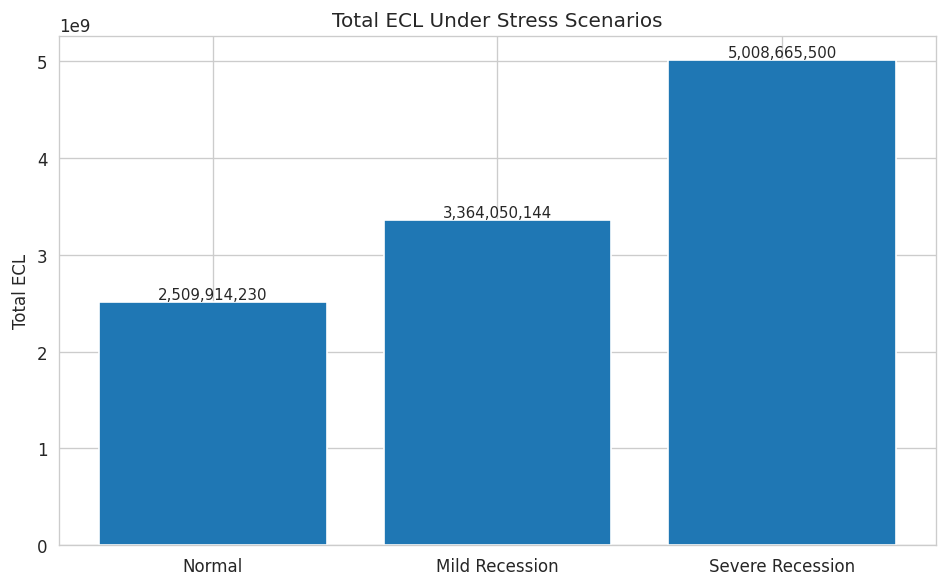

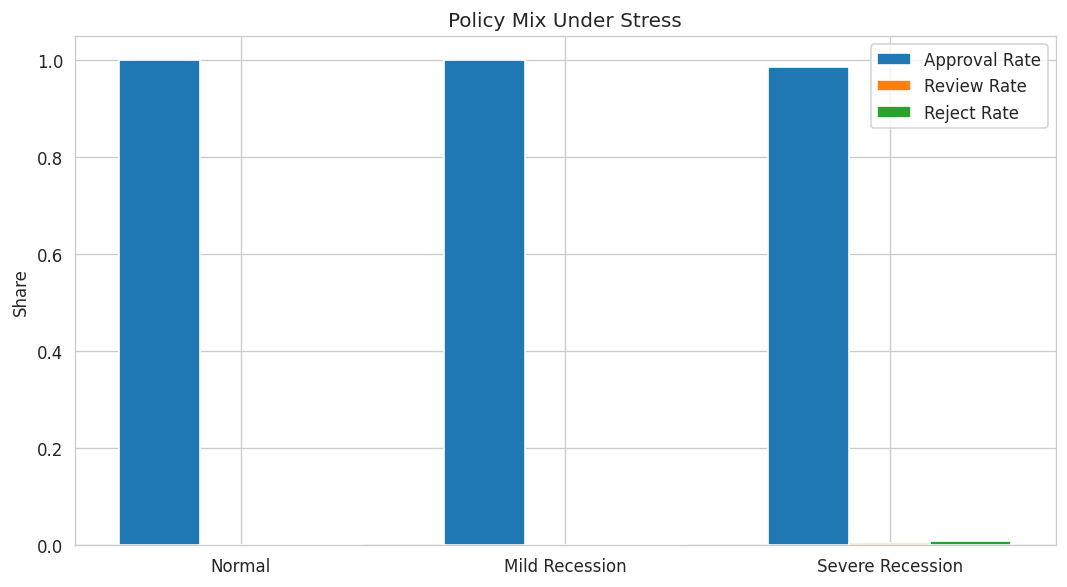


Stress testing completed successfully.


In [27]:
# ── STEP 17: STRESS TESTING MACRO SCENARIOS ───────────────
print("Running portfolio stress scenarios...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Inputs expected from previous steps:
#   y_prob_test_final         -> calibrated PD on test set
#   ead_test                  -> exposure at default proxy
#   optimal_approve_threshold -> approve threshold from Step 13
#   optimal_reject_threshold   -> reject threshold from Step 13
#   REVIEW_BAND               -> review band width from Step 13
#   band_edges, band_labels    -> from Step 14
#   stage_map                  -> from Step 15
# -----------------------------------------------------------

base_pd = np.asarray(y_prob_test_final)
base_ead = np.asarray(ead_test)

# If not already defined, keep these defaults
if "REVIEW_BAND" not in globals():
    REVIEW_BAND = 0.03

if "optimal_approve_threshold" not in globals():
    raise ValueError("optimal_approve_threshold not found. Run Step 13 first.")

if "optimal_reject_threshold" not in globals():
    optimal_reject_threshold = min(0.999, optimal_approve_threshold + REVIEW_BAND)

if "band_edges" not in globals() or "band_labels" not in globals():
    band_edges = [0.00, 0.03, 0.07, 0.15, 0.30, 1.00]
    band_labels = [
        "Very Low Risk",
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]

if "stage_map" not in globals():
    stage_map = {
        "Very Low Risk": 1,
        "Low Risk": 1,
        "Moderate Risk": 2,
        "High Risk": 3,
        "Very High Risk": 3
    }

# -----------------------------------------------------------
# Scenario assumptions
# -----------------------------------------------------------
stress_scenarios = {
    "Normal": {
        "pd_multiplier": 1.00,
        "lgd": 0.45,
        "net_margin": 0.10,
        "op_cost_rate": 0.01,
        "review_cost_rate": 0.003
    },
    "Mild Recession": {
        "pd_multiplier": 1.20,
        "lgd": 0.50,
        "net_margin": 0.08,
        "op_cost_rate": 0.012,
        "review_cost_rate": 0.004
    },
    "Severe Recession": {
        "pd_multiplier": 1.50,
        "lgd": 0.60,
        "net_margin": 0.06,
        "op_cost_rate": 0.015,
        "review_cost_rate": 0.005
    }
}

TENOR_YEARS = 3

def run_stress_scenario(
    scenario_name,
    params,
    base_pd,
    base_ead,
    approve_threshold,
    reject_threshold,
    review_band,
    band_edges,
    band_labels,
    stage_map,
    tenor_years=3
):
    """
    Portfolio stress test using stressed PD, LGD, margin, and costs.
    Decisions are made using the frozen policy thresholds.
    """

    stressed_pd = np.clip(base_pd * params["pd_multiplier"], 0, 1)

    # Risk band under stress
    stressed_band = pd.cut(
        pd.Series(stressed_pd),
        bins=band_edges,
        labels=band_labels,
        include_lowest=True,
        right=False
    )

    stressed_stage = stressed_band.map(stage_map).astype(int)

    # Simplified IFRS 9-style lifetime PD proxy:
    # Stage 1 -> 12-month PD
    # Stage 2/3 -> lifetime PD approximation
    stressed_lifetime_pd = np.where(
        stressed_stage == 1,
        stressed_pd,
        1 - (1 - stressed_pd) ** tenor_years
    )

    # ECL under stress
    stressed_ecl = stressed_lifetime_pd * params["lgd"] * base_ead

    # Frozen lending policy
    approve = stressed_pd < approve_threshold
    review = (stressed_pd >= approve_threshold) & (stressed_pd < reject_threshold)
    reject = stressed_pd >= reject_threshold

    approved_ead = base_ead[approve].sum()
    reviewed_ead = base_ead[review].sum()

    # Expected economics under stress
    expected_revenue = (base_ead[approve] * params["net_margin"] * (1 - stressed_pd[approve])).sum()
    expected_default_loss = (base_ead[approve] * params["lgd"] * stressed_pd[approve]).sum()
    operating_cost = (base_ead[approve] * params["op_cost_rate"]).sum()
    review_cost = (base_ead[review] * params["review_cost_rate"]).sum()

    expected_profit = expected_revenue - expected_default_loss - operating_cost - review_cost

    # Stage migration
    stage1_pct = (stressed_stage == 1).mean()
    stage2_pct = (stressed_stage == 2).mean()
    stage3_pct = (stressed_stage == 3).mean()

    return {
        "Scenario": scenario_name,
        "PD_Multiplier": params["pd_multiplier"],
        "LGD": params["lgd"],
        "Net_Margin": params["net_margin"],
        "Op_Cost_Rate": params["op_cost_rate"],
        "Review_Cost_Rate": params["review_cost_rate"],

        "Approval_Rate": approve.mean(),
        "Review_Rate": review.mean(),
        "Reject_Rate": reject.mean(),
        "Avg_Stressed_PD": stressed_pd.mean(),

        "Stage1_%": stage1_pct,
        "Stage2_%": stage2_pct,
        "Stage3_%": stage3_pct,

        "Approved_EAD": approved_ead,
        "Reviewed_EAD": reviewed_ead,
        "Total_EAD": base_ead.sum(),

        "Total_ECL": stressed_ecl.sum(),
        "ECL_Coverage": stressed_ecl.sum() / base_ead.sum(),

        "Expected_Revenue": expected_revenue,
        "Expected_Default_Loss": expected_default_loss,
        "Operating_Cost": operating_cost,
        "Review_Cost": review_cost,
        "Expected_Profit": expected_profit
    }

# -----------------------------------------------------------
# Run scenarios
# -----------------------------------------------------------
stress_results = []

for scenario_name, params in stress_scenarios.items():
    res = run_stress_scenario(
        scenario_name=scenario_name,
        params=params,
        base_pd=base_pd,
        base_ead=base_ead,
        approve_threshold=optimal_approve_threshold,
        reject_threshold=optimal_reject_threshold,
        review_band=REVIEW_BAND,
        band_edges=band_edges,
        band_labels=band_labels,
        stage_map=stage_map,
        tenor_years=TENOR_YEARS
    )
    stress_results.append(res)

stress_df = pd.DataFrame(stress_results)

# -----------------------------------------------------------
# Print summary
# -----------------------------------------------------------
print("\nStress Test Results:")
print(
    stress_df[[
        "Scenario",
        "Approval_Rate",
        "Review_Rate",
        "Reject_Rate",
        "Avg_Stressed_PD",
        "Stage1_%",
        "Stage2_%",
        "Stage3_%",
        "Total_ECL",
        "ECL_Coverage",
        "Expected_Profit"
    ]].to_string(index=False)
)

base_profit = stress_df.loc[stress_df["Scenario"] == "Normal", "Expected_Profit"].iloc[0]
stress_df["Profit_Uplift_vs_Normal"] = stress_df["Expected_Profit"] / base_profit - 1

print("\nProfit uplift vs Normal:")
print(
    stress_df[["Scenario", "Profit_Uplift_vs_Normal"]]
    .to_string(index=False)
)

# -----------------------------------------------------------
# Plot 1: Expected Profit under scenarios
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stress_df["Scenario"], stress_df["Expected_Profit"])
ax.set_title("Expected Portfolio Profit Under Stress Scenarios")
ax.set_ylabel("Expected Profit")
for bar, val in zip(bars, stress_df["Expected_Profit"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("plots/stress_profit.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# Plot 2: Total ECL under scenarios
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stress_df["Scenario"], stress_df["Total_ECL"])
ax.set_title("Total ECL Under Stress Scenarios")
ax.set_ylabel("Total ECL")
for bar, val in zip(bars, stress_df["Total_ECL"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:,.0f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("plots/stress_ecl.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# Plot 3: Policy mix under stress
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(stress_df))
width = 0.25

ax.bar(x - width, stress_df["Approval_Rate"], width, label="Approval Rate")
ax.bar(x, stress_df["Review_Rate"], width, label="Review Rate")
ax.bar(x + width, stress_df["Reject_Rate"], width, label="Reject Rate")

ax.set_xticks(x)
ax.set_xticklabels(stress_df["Scenario"])
ax.set_ylim(0, 1.05)
ax.set_title("Policy Mix Under Stress")
ax.set_ylabel("Share")
ax.legend()
plt.tight_layout()
plt.savefig("plots/stress_policy_mix.png", dpi=150)
plt.show()

print("\nStress testing completed successfully.")

## Step 18: SHAP Explainability

**GDPR Article 22** grants EU data subjects the right to meaningful explanation when automated decisions affect them significantly (e.g., a loan rejection). Similar requirements exist under:
- India's **Digital Personal Data Protection Act 2023** (DPDPA)
- RBI's **Fair Practice Code** for NBFCs and banks
- **Equal Credit Opportunity Act** (ECOA) in the US requires adverse action notices

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into feature contributions based on cooperative game theory (Shapley values). For each prediction:
$$f(x) = \phi_0 + \sum_{i=1}^{p} \phi_i$$

where $\phi_0$ is the baseline (average prediction) and $\phi_i$ is the contribution of feature $i$.

**Three key outputs:**
1. **Global feature importance** (mean |SHAP|): which features most influence the model overall
2. **Beeswarm plot**: direction and magnitude of each feature's impact across the dataset
3. **Individual waterfall plot**: the specific explanation for a single applicant's score (required for a GDPR right-to-explanation response)

Computing SHAP values (may take a few minutes)...
SHAP values computed.


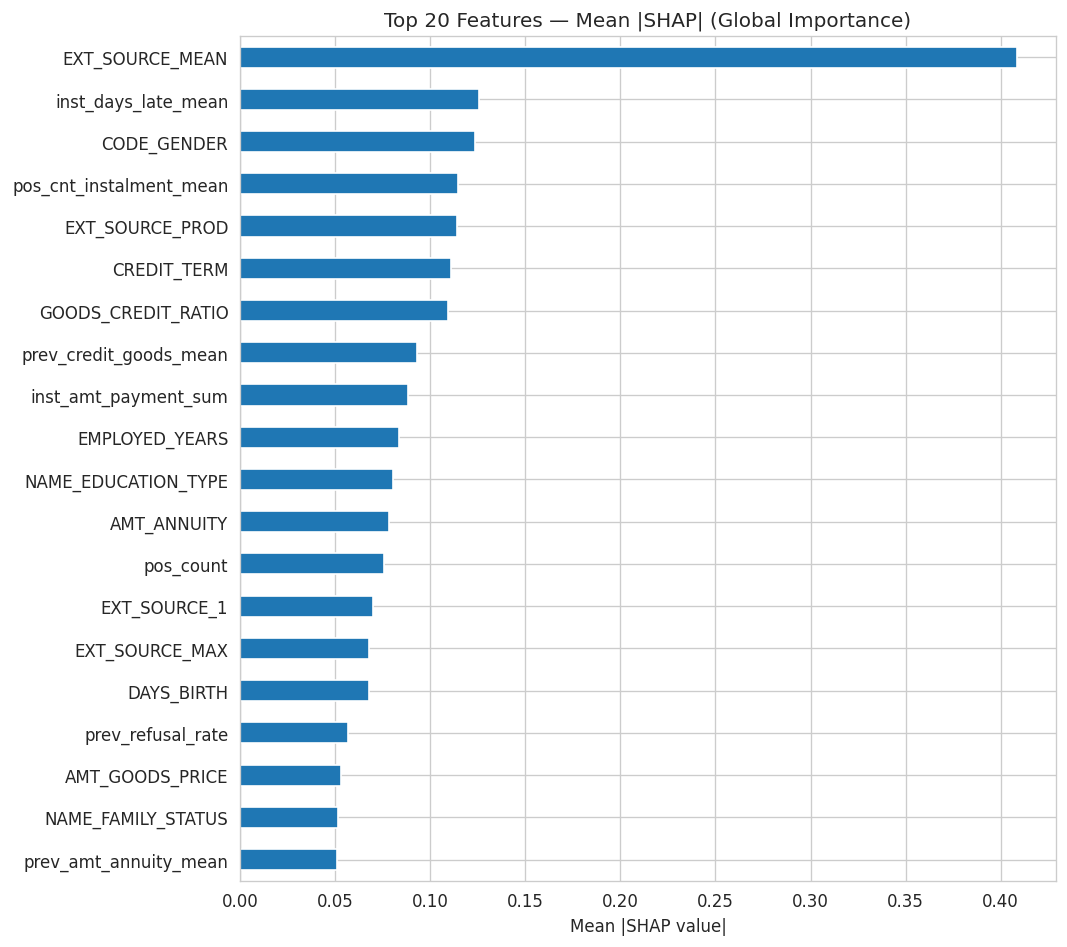

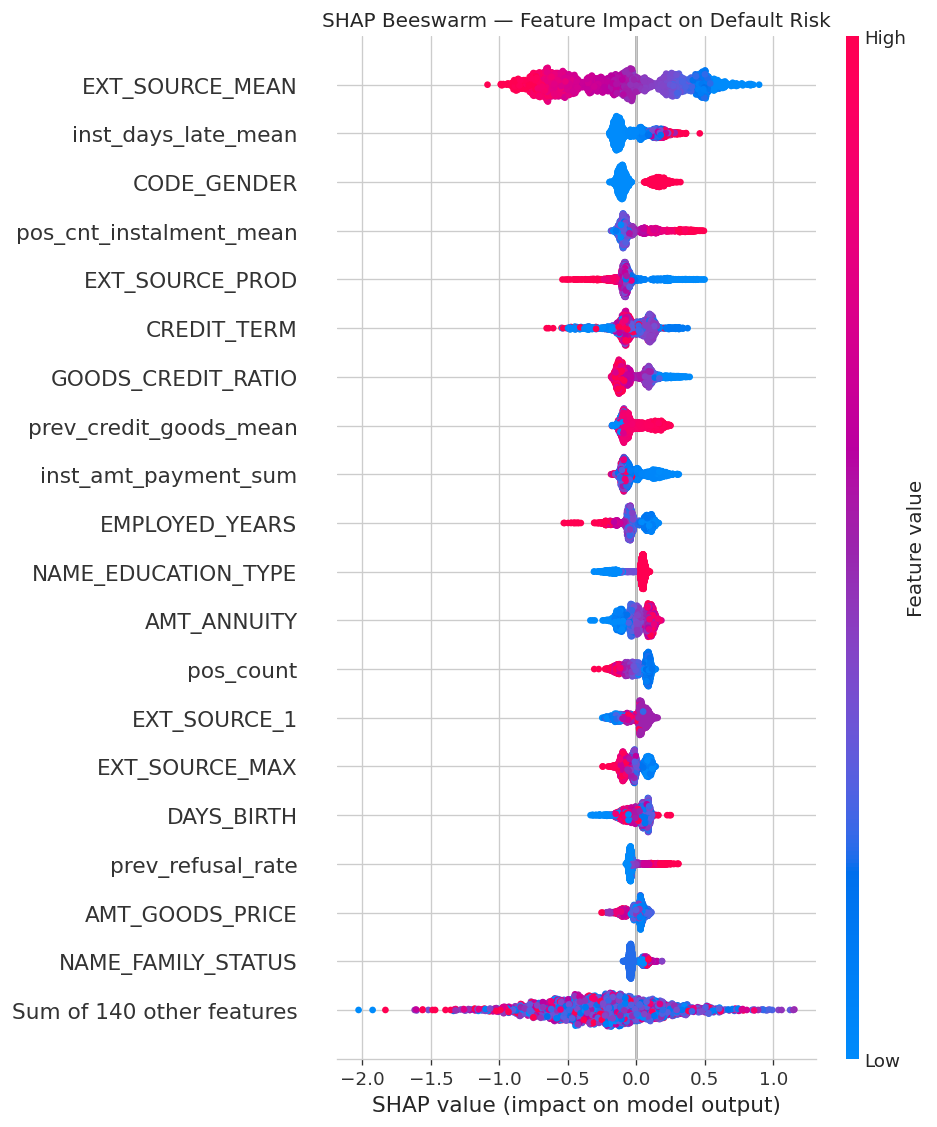


Individual explanation — highest-risk borrower in SHAP sample:
  Predicted PD: 43.9%
  Risk band: Very High Risk
  Business policy cutoff: 0.542

Top risk-reducing factors:
pos_cnt_instalment_mean   -0.076378
FLAG_OWN_CAR              -0.069301
bureau_amt_credit_mean    -0.055525
prev_credit_goods_mean    -0.036299
NAME_FAMILY_STATUS        -0.034896

Top risk-increasing factors:
CODE_GENDER          0.124845
prev_refusal_rate    0.178736
CREDIT_TERM          0.209583
EXT_SOURCE_PROD      0.291275
EXT_SOURCE_MEAN      0.571930


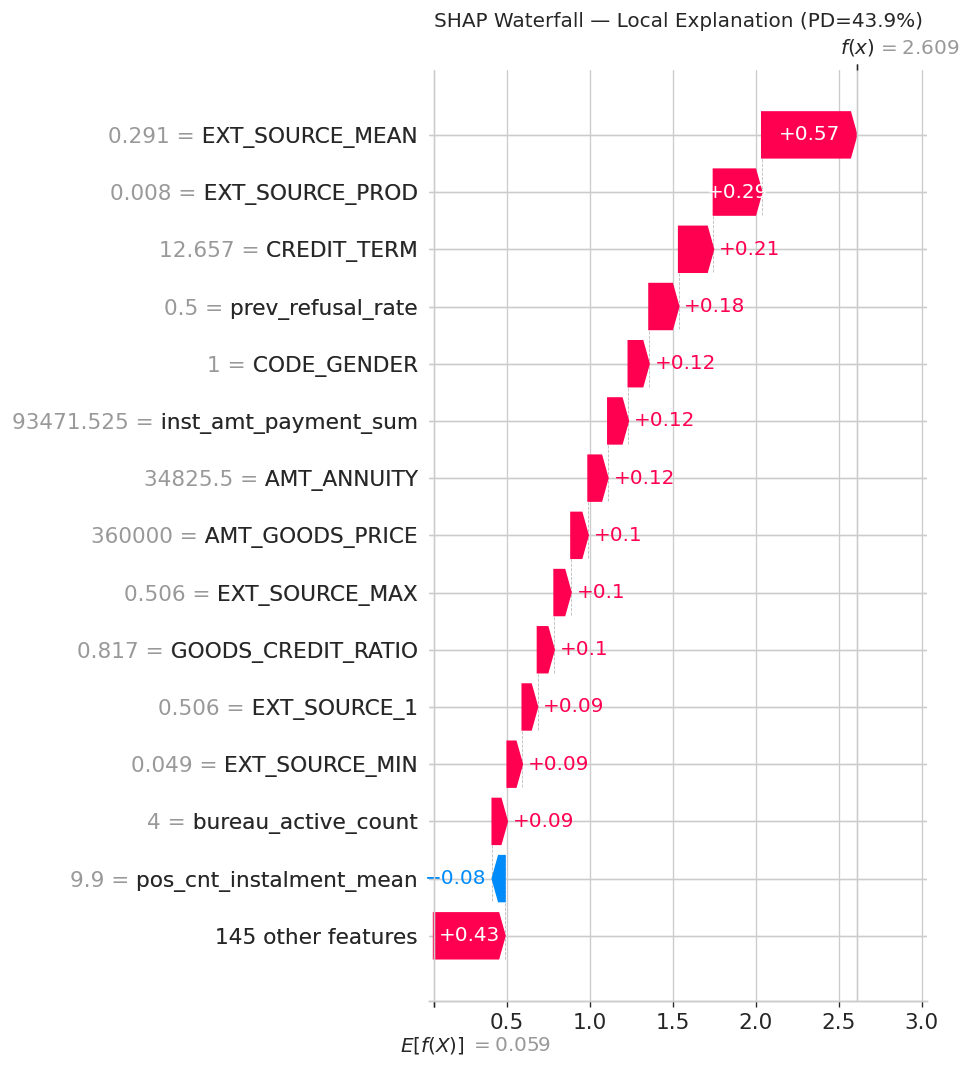


Logistic Regression coefficients:

Top 10 risk-reducing coefficients:
prev_app_credit_mean     -2.649400e-06
inst_payment_ratio_min   -9.788096e-08
bureau_amt_credit_sum    -2.735047e-08
bureau_amt_credit_mean   -7.566198e-09
inst_amt_payment_sum     -7.338556e-09
AMT_GOODS_PRICE          -5.978472e-09
CREDIT_PER_CHILD         -5.380260e-09
prev_amt_credit_mean     -8.533927e-10
INCOME_PER_CHILD         -7.189365e-10
AMT_INCOME_TOTAL         -2.785109e-10

Top 10 risk-increasing coefficients:
bureau_days_credit_mean    2.181239e-11
bureau_days_credit_min     2.945643e-11
bureau_credit_end_mean     4.620906e-11
bureau_amt_overdue_sum     7.674535e-11
cc_drawings_atm_mean       1.958159e-10
cc_drawings_mean           2.265493e-10
cc_limit_mean              2.995420e-10
cc_balance_mean            1.305023e-09
cc_balance_max             1.779081e-09
prev_amt_credit_sum        6.263330e-09


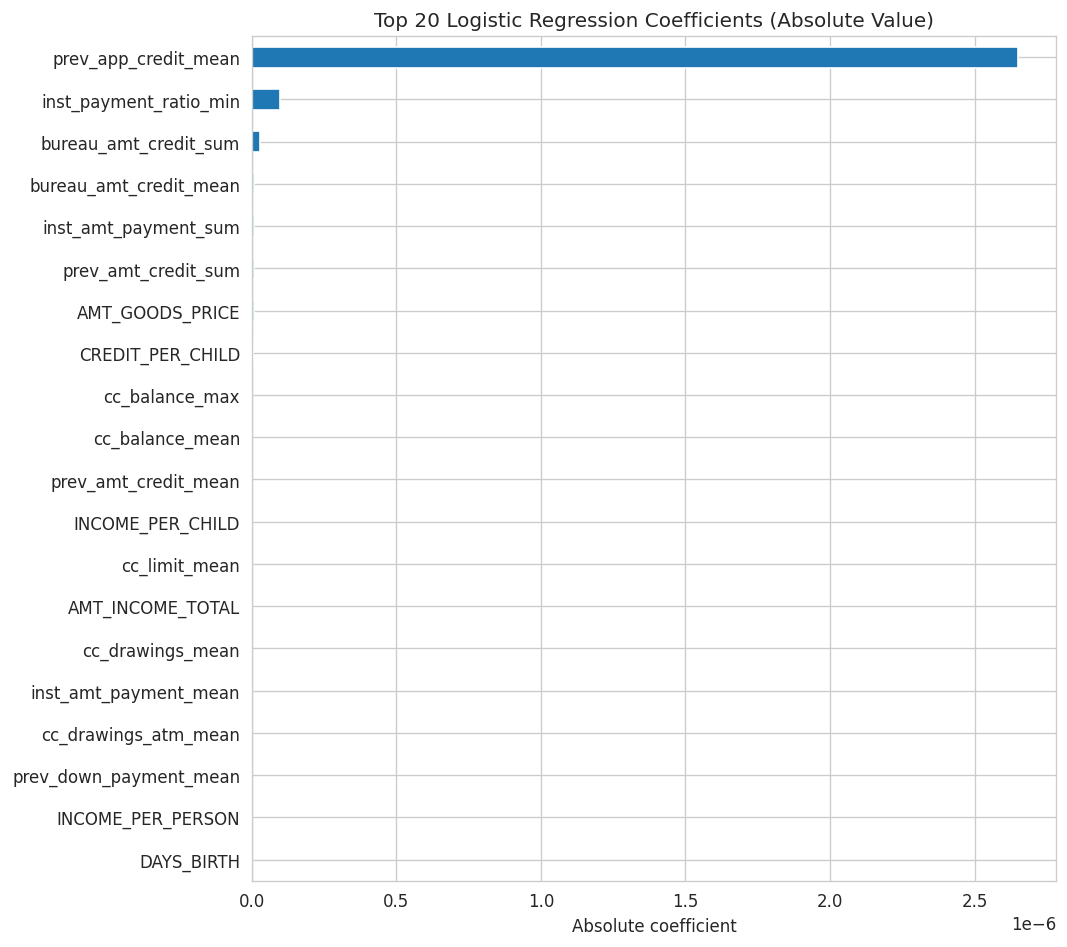


=== Explainability Step Complete ===
Key SHAP and coefficient plots saved to plots/ directory.

logistic_coefficients.png


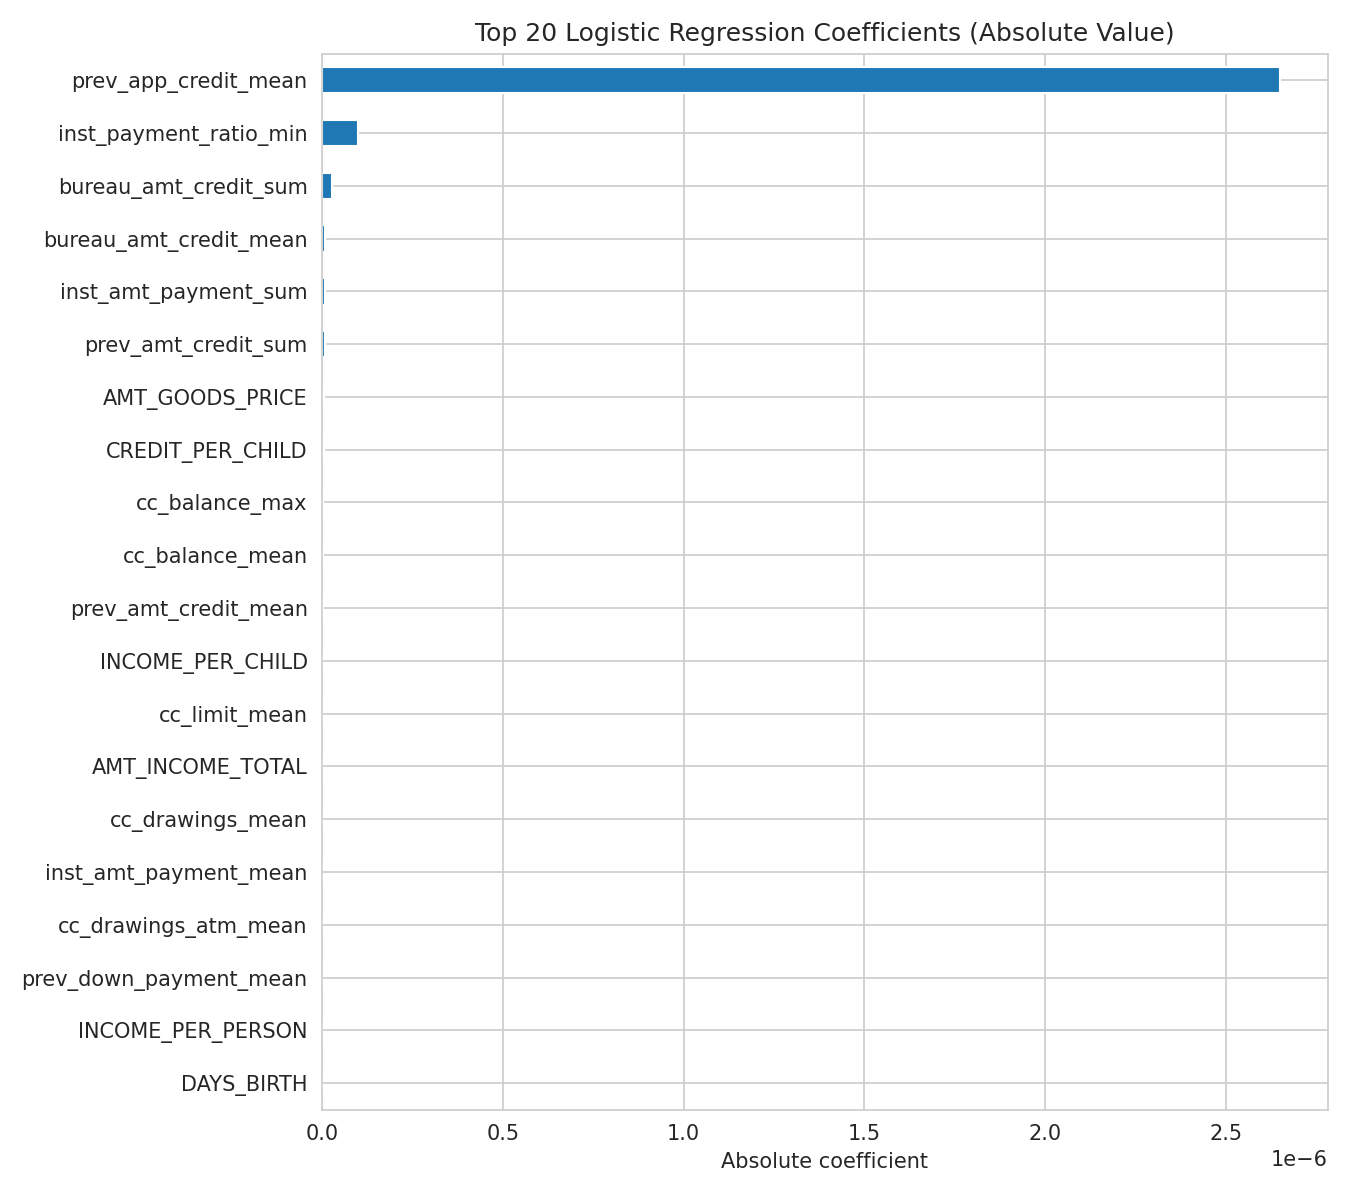

shap_beeswarm.png


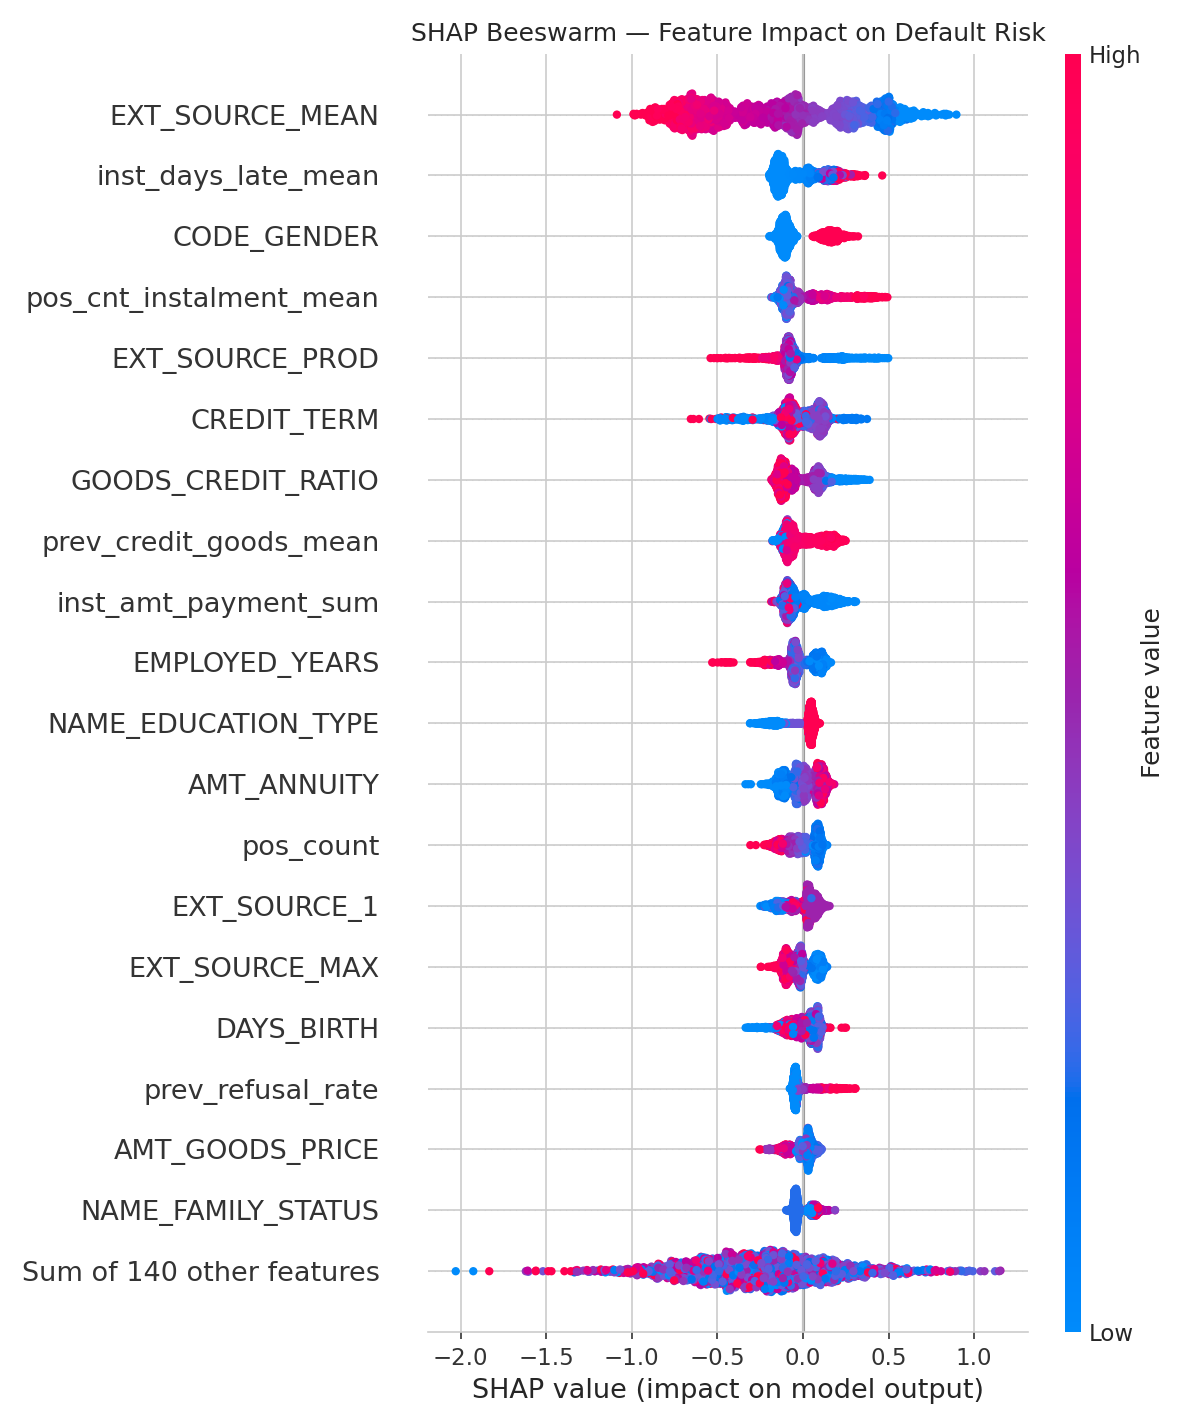

shap_global_importance.png


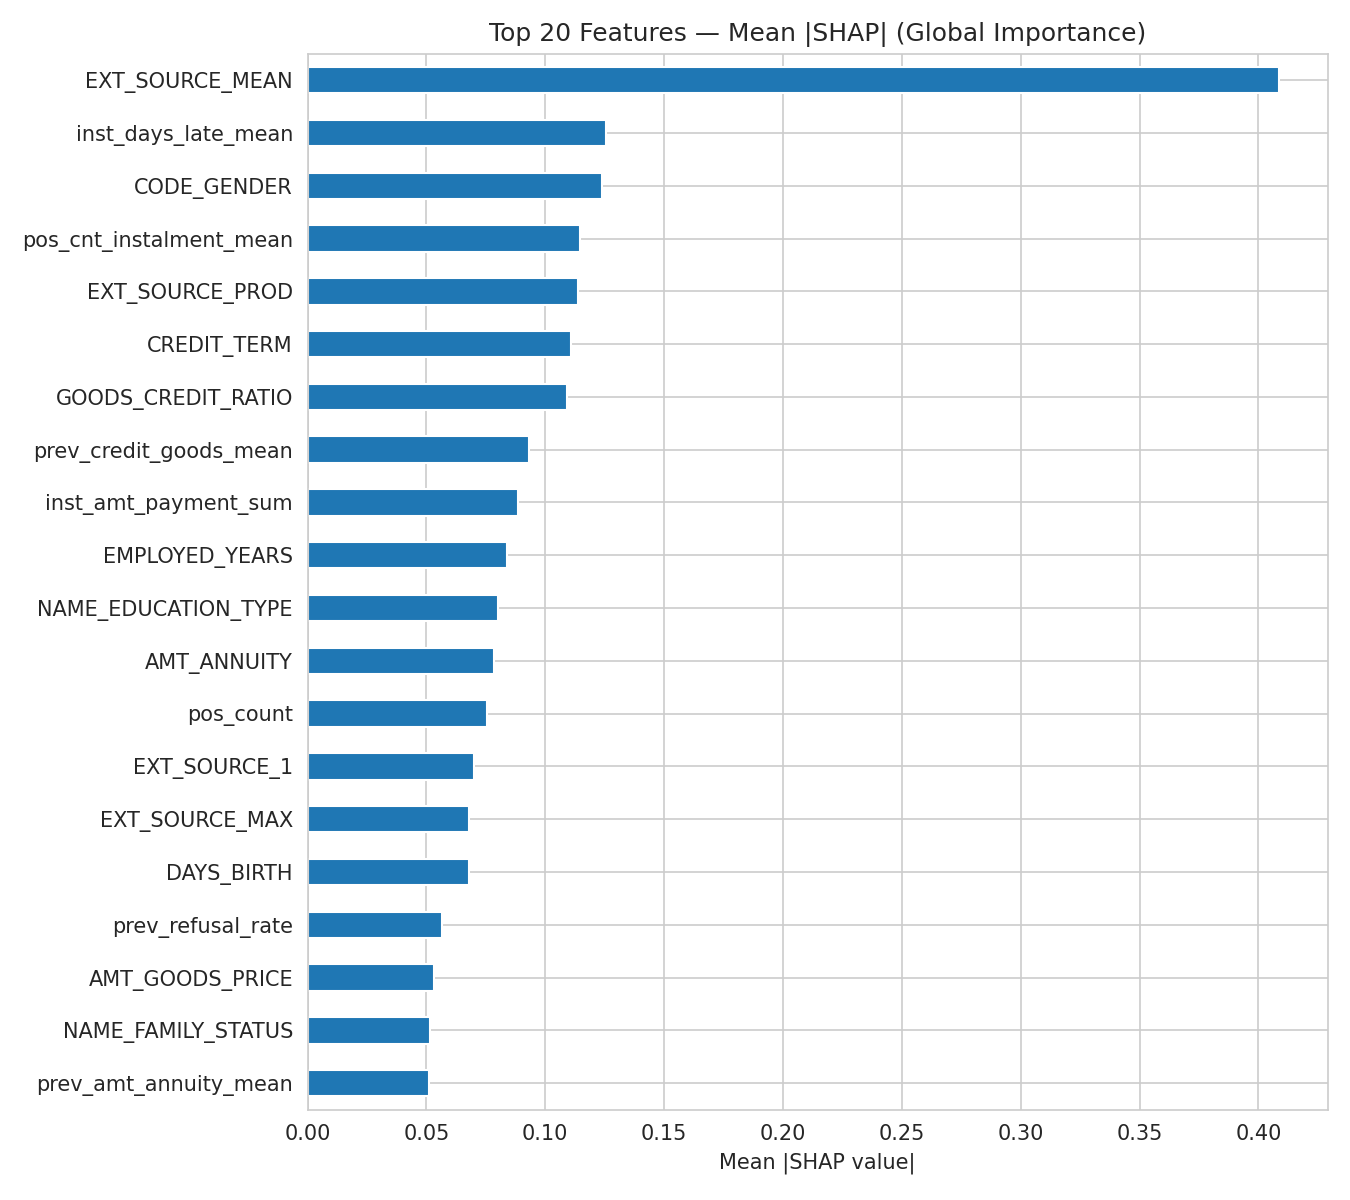

shap_waterfall_individual.png


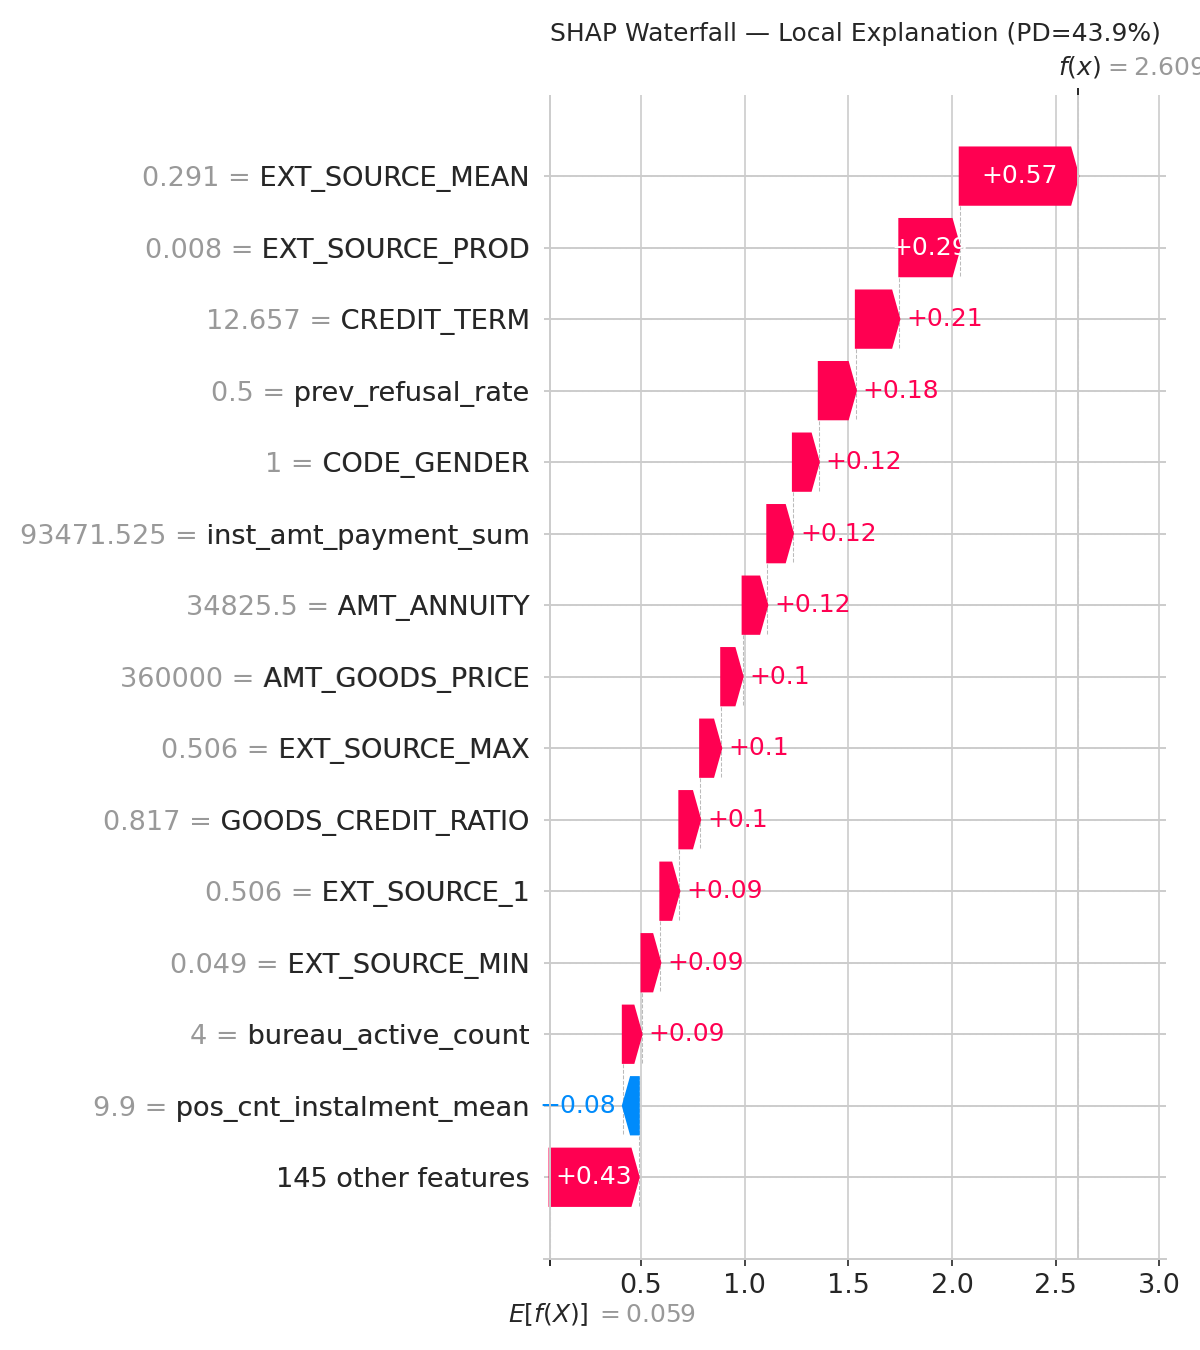

In [29]:
# ── STEP 18: SHAP EXPLAINABILITY ────────────────────────────
print("Computing SHAP values (may take a few minutes)...")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display, Image

os.makedirs("plots", exist_ok=True)

# -----------------------------------------------------------
# 1) Pick the raw tree model used for SHAP
#    Use the uncalibrated XGBoost model, not the calibrated wrapper.
# -----------------------------------------------------------
if "final_xgb_raw" in globals():
    shap_model = final_xgb_raw
elif "xgb_model" in globals():
    shap_model = xgb_model
elif "tuned_model" in globals():
    shap_model = tuned_model
else:
    raise ValueError("No XGBoost model found for SHAP explainability.")

# Logistic Regression model for coefficient interpretation
if "final_lr" in globals():
    lr_model_for_coef = final_lr
elif "lr_model" in globals():
    lr_model_for_coef = lr_model
else:
    lr_model_for_coef = None

# -----------------------------------------------------------
# 2) Sample data for SHAP
#    Keep this moderate for speed.
# -----------------------------------------------------------
N_SHAP = min(2000, len(X_test))
X_shap = X_test.sample(n=N_SHAP, random_state=RANDOM_STATE).copy()

# Optional: if there is any chance of non-numeric columns slipping in,
# convert to numeric for safety.
X_shap = X_shap.apply(pd.to_numeric, errors="coerce").fillna(0)

# -----------------------------------------------------------
# 3) SHAP explainer
#    IMPORTANT:
#    For XGBoost models with categorical splits / SHAP compatibility issues,
#    use tree_path_dependent and do NOT pass a background dataset.
# -----------------------------------------------------------
explainer = shap.TreeExplainer(
    shap_model,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer(X_shap)
print("SHAP values computed.")

# -----------------------------------------------------------
# 4) Global feature importance
# -----------------------------------------------------------
shap_mean_abs = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_shap.columns
)

top20 = shap_mean_abs.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
top20.plot(kind="barh", ax=ax)
ax.set_title("Top 20 Features — Mean |SHAP| (Global Importance)")
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig("plots/shap_global_importance.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# 5) Beeswarm plot
# -----------------------------------------------------------
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Default Risk")
plt.tight_layout()
plt.savefig("plots/shap_beeswarm.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# 6) Local explanation for one borrower
#    Choose the highest-risk borrower in the SHAP sample.
# -----------------------------------------------------------
if "y_prob_test_final" in globals():
    # Align calibrated PDs to the sampled rows
    y_prob_test_series = pd.Series(np.asarray(y_prob_test_final), index=X_test.index)
    local_pd = y_prob_test_series.loc[X_shap.index].to_numpy()
    worst_idx = int(np.argmax(local_pd))
    local_pd_value = float(local_pd[worst_idx])
else:
    # Fallback to raw model probability
    raw_pd = shap_model.predict_proba(X_shap)[:, 1]
    worst_idx = int(np.argmax(raw_pd))
    local_pd_value = float(raw_pd[worst_idx])

worst_row = X_shap.iloc[worst_idx]

# Risk band if available
worst_risk_band = None
if "band_edges" in globals() and "band_labels" in globals():
    worst_risk_band = pd.cut(
        pd.Series([local_pd_value]),
        bins=band_edges,
        labels=band_labels,
        include_lowest=True,
        right=False
    ).iloc[0]

print("\nIndividual explanation — highest-risk borrower in SHAP sample:")
print(f"  Predicted PD: {local_pd_value:.1%}")
if worst_risk_band is not None:
    print(f"  Risk band: {worst_risk_band}")
if "optimal_approve_threshold" in globals():
    print(f"  Business policy cutoff: {optimal_approve_threshold:.3f}")

# Top positive / negative SHAP contributions for this borrower
local_shap = pd.Series(shap_values.values[worst_idx], index=X_shap.columns).sort_values()

print("\nTop risk-reducing factors:")
print(local_shap.head(5).to_string())

print("\nTop risk-increasing factors:")
print(local_shap.tail(5).to_string())

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[worst_idx], max_display=15, show=False)
plt.title(f"SHAP Waterfall — Local Explanation (PD={local_pd_value:.1%})")
plt.tight_layout()
plt.savefig("plots/shap_waterfall_individual.png", dpi=150)
plt.show()

# -----------------------------------------------------------
# 7) Logistic Regression coefficients
# -----------------------------------------------------------
if lr_model_for_coef is not None:
    coef_cols = X_train_full.columns if "X_train_full" in globals() else X_train.columns

    lr_coef = pd.Series(
        lr_model_for_coef.coef_[0],
        index=coef_cols
    ).sort_values()

    print("\nLogistic Regression coefficients:")

    print("\nTop 10 risk-reducing coefficients:")
    print(lr_coef.head(10).to_string())

    print("\nTop 10 risk-increasing coefficients:")
    print(lr_coef.tail(10).to_string())

    # Optional coefficient plot
    coef_top = lr_coef.abs().nlargest(20).sort_values()
    fig, ax = plt.subplots(figsize=(9, 8))
    coef_top.plot(kind="barh", ax=ax)
    ax.set_title("Top 20 Logistic Regression Coefficients (Absolute Value)")
    ax.set_xlabel("Absolute coefficient")
    plt.tight_layout()
    plt.savefig("plots/logistic_coefficients.png", dpi=150)
    plt.show()

# -----------------------------------------------------------
# 8) Show saved plots
# -----------------------------------------------------------
print("\n=== Explainability Step Complete ===")
print("Key SHAP and coefficient plots saved to plots/ directory.\n")

for fname in sorted(os.listdir("plots")):
    if fname.endswith(".png") and (
        "shap" in fname or "logistic_coefficients" in fname
    ):
        print(fname)
        display(Image(f"plots/{fname}"))

## Step 19: Export Artifacts

In [30]:
import joblib
import json
import os

os.makedirs("artifacts", exist_ok=True)

joblib.dump(final_xgb_raw, "artifacts/final_xgb_raw.pkl")
joblib.dump(calibrated_model, "artifacts/calibrated_xgb.pkl")
joblib.dump(final_lr, "artifacts/final_lr.pkl")

feature_cols = X_train_full.columns.tolist()  # or the final model feature list
with open("artifacts/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

policy_config = {
    "approve_threshold": float(optimal_approve_threshold),
    "reject_threshold": float(optimal_reject_threshold),
    "review_band": float(REVIEW_BAND),
    "lgd": 0.45,
    "net_margin": 0.10,
    "operating_cost_rate": 0.01,
    "review_cost_rate": 0.003,
    "risk_band_edges": [0.00, 0.03, 0.07, 0.15, 0.30, 1.00],
    "risk_band_labels": [
        "Very Low Risk",
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
}

with open("artifacts/policy_config.json", "w") as f:
    json.dump(policy_config, f, indent=2)


import pandas as pd

pd.Series(np.asarray(y_prob_val_final)).to_csv("artifacts/psi_reference_scores.csv", index=False)

val_band_summary.to_csv("artifacts/validation_risk_band_summary.csv", index=False)
stage_summary.to_csv("artifacts/ecl_stage_summary.csv", index=False)
stress_df.to_csv("artifacts/stress_results.csv", index=False)

In [31]:
!zip -r artifacts.zip artifacts

  adding: artifacts/ (stored 0%)
  adding: artifacts/final_lr.pkl (deflated 41%)
  adding: artifacts/stress_results.csv (deflated 46%)
  adding: artifacts/validation_risk_band_summary.csv (deflated 34%)
  adding: artifacts/ecl_stage_summary.csv (deflated 43%)
  adding: artifacts/feature_cols.json (deflated 68%)
  adding: artifacts/psi_reference_scores.csv (deflated 58%)
  adding: artifacts/final_xgb_raw.pkl (deflated 75%)
  adding: artifacts/calibrated_xgb.pkl (deflated 75%)
  adding: artifacts/policy_config.json (deflated 50%)


In [32]:
!zip -r plots.zip plots

  adding: plots/ (stored 0%)
  adding: plots/psi_by_bin.png (deflated 18%)
  adding: plots/risk_bands.png (deflated 19%)
  adding: plots/stress_policy_mix.png (deflated 25%)
  adding: plots/approval_bad_rate_tradeoff.png (deflated 9%)
  adding: plots/profit_vs_threshold_constrained.png (deflated 12%)
  adding: plots/logistic_coefficients.png (deflated 21%)
  adding: plots/shap_beeswarm.png (deflated 6%)
  adding: plots/stress_profit.png (deflated 21%)
  adding: plots/shap_global_importance.png (deflated 21%)
  adding: plots/calibration_curve.png (deflated 11%)
  adding: plots/ecl_scenarios.png (deflated 23%)
  adding: plots/stress_ecl.png (deflated 23%)
  adding: plots/ecl_by_stage.png (deflated 25%)
  adding: plots/shap_waterfall_individual.png (deflated 11%)
  adding: plots/profit_vs_threshold.png (deflated 11%)
  adding: plots/risk_growth_tradeoff_constrained.png (deflated 6%)
  adding: plots/ks_roc_curves.png (deflated 10%)
